In [8]:
# Option 1: Clear pip cache
!rm -rf ~/.cache/pip

# Option 2: Clear HuggingFace cache (if you've downloaded models before)
!rm -rf ~/.cache/huggingface

# Option 3: Clear Jupyter checkpoints
!find ~ -name ".ipynb_checkpoints" -exec rm -rf {} +

!pip cache purge

import os
os.environ['PIP_CACHE_DIR'] = '/nfs/roberts/project/cpsc4710/cpsc4710_ag2995/project/.pip_cache'

# Install with no cache (cleaner)
!pip install --no-cache-dir -r requirements.txt

# Also set HuggingFace cache to project directory (saves space in home)
os.environ['HF_HOME'] = '/nfs/roberts/project/cpsc4710/cpsc4710_ag2995/project/.huggingface_cache'
os.environ['TRANSFORMERS_CACHE'] = '/nfs/roberts/project/cpsc4710/cpsc4710_ag2995/project/.huggingface_cache'

rm: cannot remove '/home/cpsc4710_ag2995/.cache/huggingface/xet/logs': Directory not empty
Files removed: 0
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [1]:
import nltk
nltk.download('punkt')

# Cell 2: Imports
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm  # Use notebook version for better display
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

from transformers import (
    AutoProcessor, 
    AutoModelForVision2Seq,
    get_cosine_schedule_with_warmup
)
from datasets import load_dataset
from PIL import Image
import torchvision.transforms as transforms

# For evaluation metrics
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.metrics import roc_auc_score
from scipy.stats import entropy

# For inline plotting
%matplotlib inline

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Verify setup
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

[nltk_data] Downloading package punkt to
[nltk_data]     /home/cpsc4710_ag2995/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


PyTorch: 2.9.1+cu128
CUDA available: True
GPU: NVIDIA RTX 5000 Ada Generation


In [3]:
import random
import numpy as np
from collections import Counter, defaultdict
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

class COCOBiasAnalyzer:
    """Analyze MS-COCO captions for gender and other biases"""
    
    def __init__(self):
        # Gender-related terms
        self.male_terms = ['man', 'men', 'male', 'boy', 'boys', 'gentleman', 'guy', 'guys', 'he', 'him', 'his']
        self.female_terms = ['woman', 'women', 'female', 'girl', 'girls', 'lady', 'ladies', 'she', 'her']
        
        # Activity verbs
        self.active_verbs = [
            'playing', 'riding', 'jumping', 'running', 'working', 'skiing', 
            'surfing', 'skateboarding', 'competing', 'performing', 'leading', 
            'driving', 'flying', 'throwing', 'kicking', 'hitting'
        ]
        self.passive_verbs = [
            'sitting', 'standing', 'watching', 'waiting', 'resting', 'posing', 
            'looking', 'holding', 'carrying', 'wearing', 'laying', 'lying'
        ]
        
        # Professional vs domestic contexts
        self.professional_contexts = [
            'office', 'business', 'meeting', 'conference', 'computer', 'desk',
            'suit', 'tie', 'briefcase', 'presentation', 'workplace'
        ]
        self.domestic_contexts = [
            'kitchen', 'cooking', 'baby', 'child', 'children', 'home', 
            'cleaning', 'laundry', 'shopping', 'grocery', 'family'
        ]
        
        # Sports and activities
        self.sports = [
            'baseball', 'football', 'soccer', 'basketball', 'tennis', 
            'skateboarding', 'skiing', 'surfing', 'snowboarding'
        ]
        
    def load_coco_data(self, num_samples=10000):
        """Load COCO captions"""
        print("Loading COCO dataset...")
        
        # Load train split
        dataset = load_dataset("yerevann/coco-karpathy", split='train')
        num_samples = len(dataset)-1
        
        # Sample for analysis
        if num_samples < len(dataset):
            indices = random.sample(range(len(dataset)), num_samples)
            dataset = dataset.select(indices)
        
        print(f"Loaded {len(dataset)} samples for analysis")
        
        # Extract all captions
        all_captions = []
        for example in dataset:
            captions = example['sentences']
            all_captions.extend(captions)
        
        print(f"Total captions: {len(all_captions)}")
        return all_captions
    
    def analyze_gender_mentions(self, captions):
        """Analyze how often male vs female terms appear"""
        print("\n" + "="*80)
        print("GENDER MENTION ANALYSIS")
        print("="*80)
        
        male_count = 0
        female_count = 0
        both_count = 0
        neither_count = 0
        
        male_captions = []
        female_captions = []
        
        for caption in captions:
            caption_lower = caption.lower()
            has_male = any(term in caption_lower for term in self.male_terms)
            has_female = any(term in caption_lower for term in self.female_terms)
            
            if has_male and has_female:
                both_count += 1
            elif has_male:
                male_count += 1
                male_captions.append(caption)
            elif has_female:
                female_count += 1
                female_captions.append(caption)
            else:
                neither_count += 1
        
        total = len(captions)
        
        print(f"\nGender Mention Statistics:")
        print(f"  Male only: {male_count} ({male_count/total*100:.1f}%)")
        print(f"  Female only: {female_count} ({female_count/total*100:.1f}%)")
        print(f"  Both: {both_count} ({both_count/total*100:.1f}%)")
        print(f"  Neither: {neither_count} ({neither_count/total*100:.1f}%)")
        
        print(f"\n📊 BIAS INDICATOR:")
        if male_count > female_count:
            ratio = male_count / female_count if female_count > 0 else float('inf')
            print(f"  ⚠️  MALE BIAS: Males mentioned {ratio:.2f}x more than females")
        elif female_count > male_count:
            ratio = female_count / male_count if male_count > 0 else float('inf')
            print(f"  ⚠️  FEMALE BIAS: Females mentioned {ratio:.2f}x more than males")
        else:
            print(f"  ✓ BALANCED: Equal gender representation")
        
        return {
            'male_captions': male_captions,
            'female_captions': female_captions,
            'male_count': male_count,
            'female_count': female_count
        }
    
    def analyze_gender_activities(self, male_captions, female_captions):
        """Analyze if males/females are associated with different activities"""
        print("\n" + "="*80)
        print("GENDER × ACTIVITY ANALYSIS")
        print("="*80)
        
        # Count active vs passive for each gender
        male_active = sum(1 for c in male_captions if any(v in c.lower() for v in self.active_verbs))
        male_passive = sum(1 for c in male_captions if any(v in c.lower() for v in self.passive_verbs))
        
        female_active = sum(1 for c in female_captions if any(v in c.lower() for v in self.active_verbs))
        female_passive = sum(1 for c in female_captions if any(v in c.lower() for v in self.passive_verbs))
        
        print(f"\nActivity Distribution:")
        print(f"  Male:")
        print(f"    Active verbs: {male_active} ({male_active/len(male_captions)*100:.1f}%)")
        print(f"    Passive verbs: {male_passive} ({male_passive/len(male_captions)*100:.1f}%)")
        
        print(f"  Female:")
        print(f"    Active verbs: {female_active} ({female_active/len(female_captions)*100:.1f}%)")
        print(f"    Passive verbs: {female_passive} ({female_passive/len(female_captions)*100:.1f}%)")
        
        # Compute bias
        male_active_rate = male_active / len(male_captions) if len(male_captions) > 0 else 0
        female_active_rate = female_active / len(female_captions) if len(female_captions) > 0 else 0
        
        activity_bias = abs(male_active_rate - female_active_rate)
        
        print(f"\n📊 ACTIVITY BIAS:")
        print(f"  Male active rate: {male_active_rate:.3f}")
        print(f"  Female active rate: {female_active_rate:.3f}")
        print(f"  Difference: {activity_bias:.3f}")
        
        if activity_bias > 0.05:
            if male_active_rate > female_active_rate:
                print(f"  ⚠️  BIAS DETECTED: Males more associated with active activities")
            else:
                print(f"  ⚠️  BIAS DETECTED: Females more associated with active activities")
        else:
            print(f"  ✓ NO SIGNIFICANT ACTIVITY BIAS")
        
        return {
            'male_active_rate': male_active_rate,
            'female_active_rate': female_active_rate,
            'activity_bias': activity_bias
        }
    
    def analyze_gender_contexts(self, male_captions, female_captions):
        """Analyze if males/females appear in different contexts"""
        print("\n" + "="*80)
        print("GENDER × CONTEXT ANALYSIS")
        print("="*80)
        
        # Professional vs domestic contexts
        male_prof = sum(1 for c in male_captions if any(ctx in c.lower() for ctx in self.professional_contexts))
        male_domestic = sum(1 for c in male_captions if any(ctx in c.lower() for ctx in self.domestic_contexts))
        
        female_prof = sum(1 for c in female_captions if any(ctx in c.lower() for ctx in self.professional_contexts))
        female_domestic = sum(1 for c in female_captions if any(ctx in c.lower() for ctx in self.domestic_contexts))
        
        print(f"\nContext Distribution:")
        print(f"  Male:")
        print(f"    Professional: {male_prof} ({male_prof/len(male_captions)*100:.1f}%)")
        print(f"    Domestic: {male_domestic} ({male_domestic/len(male_captions)*100:.1f}%)")
        
        print(f"  Female:")
        print(f"    Professional: {female_prof} ({female_prof/len(female_captions)*100:.1f}%)")
        print(f"    Domestic: {female_domestic} ({female_domestic/len(female_captions)*100:.1f}%)")
        
        # Compute bias
        male_prof_rate = male_prof / len(male_captions) if len(male_captions) > 0 else 0
        female_prof_rate = female_prof / len(female_captions) if len(female_captions) > 0 else 0
        
        male_domestic_rate = male_domestic / len(male_captions) if len(male_captions) > 0 else 0
        female_domestic_rate = female_domestic / len(female_captions) if len(female_captions) > 0 else 0
        
        prof_bias = abs(male_prof_rate - female_prof_rate)
        domestic_bias = abs(male_domestic_rate - female_domestic_rate)
        
        print(f"\n📊 CONTEXT BIAS:")
        print(f"  Professional context difference: {prof_bias:.3f}")
        print(f"  Domestic context difference: {domestic_bias:.3f}")
        
        if domestic_bias > 0.02:
            if female_domestic_rate > male_domestic_rate:
                print(f"  ⚠️  BIAS DETECTED: Females more associated with domestic contexts")
            else:
                print(f"  ⚠️  BIAS DETECTED: Males more associated with domestic contexts")
        
        return {
            'male_prof_rate': male_prof_rate,
            'female_prof_rate': female_prof_rate,
            'male_domestic_rate': male_domestic_rate,
            'female_domestic_rate': female_domestic_rate,
            'prof_bias': prof_bias,
            'domestic_bias': domestic_bias
        }
    
    def analyze_gender_sports(self, male_captions, female_captions):
        """Analyze sports representation by gender"""
        print("\n" + "="*80)
        print("GENDER × SPORTS ANALYSIS")
        print("="*80)
        
        male_sports = sum(1 for c in male_captions if any(sport in c.lower() for sport in self.sports))
        female_sports = sum(1 for c in female_captions if any(sport in c.lower() for sport in self.sports))
        
        male_sports_rate = male_sports / len(male_captions) if len(male_captions) > 0 else 0
        female_sports_rate = female_sports / len(female_captions) if len(female_captions) > 0 else 0
        
        print(f"\nSports Representation:")
        print(f"  Male sports mentions: {male_sports} ({male_sports_rate*100:.1f}%)")
        print(f"  Female sports mentions: {female_sports} ({female_sports_rate*100:.1f}%)")
        
        sports_bias = abs(male_sports_rate - female_sports_rate)
        
        print(f"\n📊 SPORTS BIAS:")
        print(f"  Difference: {sports_bias:.3f}")
        
        if sports_bias > 0.05:
            if male_sports_rate > female_sports_rate:
                print(f"  ⚠️  BIAS DETECTED: Males more represented in sports")
            else:
                print(f"  ⚠️  BIAS DETECTED: Females more represented in sports")
        
        return {
            'male_sports_rate': male_sports_rate,
            'female_sports_rate': female_sports_rate,
            'sports_bias': sports_bias
        }
    
    def show_example_captions(self, male_captions, female_captions):
        """Show example captions for each gender"""
        print("\n" + "="*80)
        print("EXAMPLE CAPTIONS")
        print("="*80)
        
        print("\n📝 Male-mentioning captions:")
        for i, caption in enumerate(random.sample(male_captions, min(10, len(male_captions))), 1):
            print(f"  {i}. {caption}")
        
        print("\n📝 Female-mentioning captions:")
        for i, caption in enumerate(random.sample(female_captions, min(10, len(female_captions))), 1):
            print(f"  {i}. {caption}")
    
    def generate_bias_report(self):
        """Generate comprehensive bias analysis report"""
        print("\n" + "="*80)
        print("COCO CAPTION BIAS ANALYSIS")
        print("="*80)
        
        # Load data
        captions = self.load_coco_data(num_samples=10000)
        
        # Analyze gender mentions
        gender_data = self.analyze_gender_mentions(captions)
        
        # Analyze activities
        activity_data = self.analyze_gender_activities(
            gender_data['male_captions'], 
            gender_data['female_captions']
        )
        
        # Analyze contexts
        context_data = self.analyze_gender_contexts(
            gender_data['male_captions'], 
            gender_data['female_captions']
        )
        
        # Analyze sports
        sports_data = self.analyze_gender_sports(
            gender_data['male_captions'], 
            gender_data['female_captions']
        )
        
        # Show examples
        self.show_example_captions(
            gender_data['male_captions'], 
            gender_data['female_captions']
        )
        
        # Summary
        print("\n" + "="*80)
        print("SUMMARY: BIAS IN COCO CAPTIONS")
        print("="*80)
        
        print(f"\n1. Gender Representation Bias:")
        print(f"   Male/Female ratio: {gender_data['male_count']/gender_data['female_count']:.2f}")
        
        print(f"\n2. Activity Bias:")
        print(f"   Male active rate: {activity_data['male_active_rate']:.3f}")
        print(f"   Female active rate: {activity_data['female_active_rate']:.3f}")
        print(f"   Bias magnitude: {activity_data['activity_bias']:.3f}")
        
        print(f"\n3. Context Bias:")
        print(f"   Domestic context bias: {context_data['domestic_bias']:.3f}")
        print(f"   Professional context bias: {context_data['prof_bias']:.3f}")
        
        print(f"\n4. Sports Representation Bias:")
        print(f"   Bias magnitude: {sports_data['sports_bias']:.3f}")
        
        print("\n" + "="*80)
        print("✓ ANALYSIS COMPLETE")
        print("="*80)
        
        return {
            'gender': gender_data,
            'activity': activity_data,
            'context': context_data,
            'sports': sports_data
        }

# ============================================
# RUN ANALYSIS
# ============================================

if __name__ == "__main__":
    analyzer = COCOBiasAnalyzer()
    results = analyzer.generate_bias_report()


COCO CAPTION BIAS ANALYSIS
Loading COCO dataset...
Loaded 82782 samples for analysis
Total captions: 414108

GENDER MENTION ANALYSIS

Gender Mention Statistics:
  Male only: 166779 (40.3%)
  Female only: 4347 (1.0%)
  Both: 73030 (17.6%)
  Neither: 169952 (41.0%)

📊 BIAS INDICATOR:
  ⚠️  MALE BIAS: Males mentioned 38.37x more than females

GENDER × ACTIVITY ANALYSIS

Activity Distribution:
  Male:
    Active verbs: 24399 (14.6%)
    Passive verbs: 50010 (30.0%)
  Female:
    Active verbs: 743 (17.1%)
    Passive verbs: 2290 (52.7%)

📊 ACTIVITY BIAS:
  Male active rate: 0.146
  Female active rate: 0.171
  Difference: 0.025
  ✓ NO SIGNIFICANT ACTIVITY BIAS

GENDER × CONTEXT ANALYSIS

Context Distribution:
  Male:
    Professional: 7807 (4.7%)
    Domestic: 11804 (7.1%)
  Female:
    Professional: 175 (4.0%)
    Domestic: 100 (2.3%)

📊 CONTEXT BIAS:
  Professional context difference: 0.007
  Domestic context difference: 0.048
  ⚠️  BIAS DETECTED: Males more associated with domestic conte

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'nlphuji/flickr30k' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Lin-Chen/flickr30k' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'sentence-transformers/flickr30k-captions' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.



FLICKR30K COMPREHENSIVE BIAS ANALYSIS
LOADING FLICKR30K DATASET
Strategy 1: Loading from nlphuji/flickr30k...
✗ Failed: Dataset scripts are no longer supported, but found flickr30k.py

Strategy 2: Loading from Lin-Chen/flickr30k...
✗ Failed: Dataset 'Lin-Chen/flickr30k' doesn't exist on the Hub or cannot be accessed.

Strategy 3: Loading from sentence-transformers/flickr30k-captions...
✓ Loaded: 158881 samples

Extracting captions...
  Processed 0/158881 samples...
  Processed 1000/158881 samples...
  Processed 2000/158881 samples...
  Processed 3000/158881 samples...
  Processed 4000/158881 samples...
  Processed 5000/158881 samples...
  Processed 6000/158881 samples...
  Processed 7000/158881 samples...
  Processed 8000/158881 samples...
  Processed 9000/158881 samples...
  Processed 10000/158881 samples...
  Processed 11000/158881 samples...
  Processed 12000/158881 samples...
  Processed 13000/158881 samples...
  Processed 14000/158881 samples...
  Processed 15000/158881 samples..

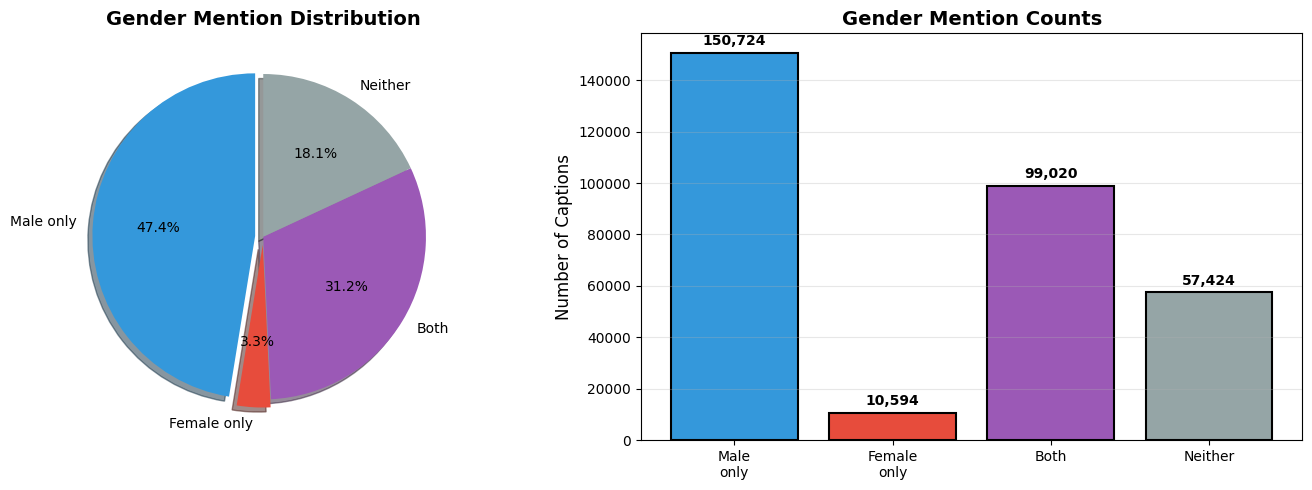


2. GENDER × ACTIVITY ANALYSIS

Activity Distribution:
  Male:
    Active verbs: 28,190 (18.7%)
    Passive verbs: 56,210 (37.3%)
  Female:
    Active verbs: 1,968 (18.6%)
    Passive verbs: 4,230 (39.9%)

📊 ACTIVITY BIAS: 0.001
  ✓ No significant activity bias

✓ Saved: flickr30k_activity_bias.png


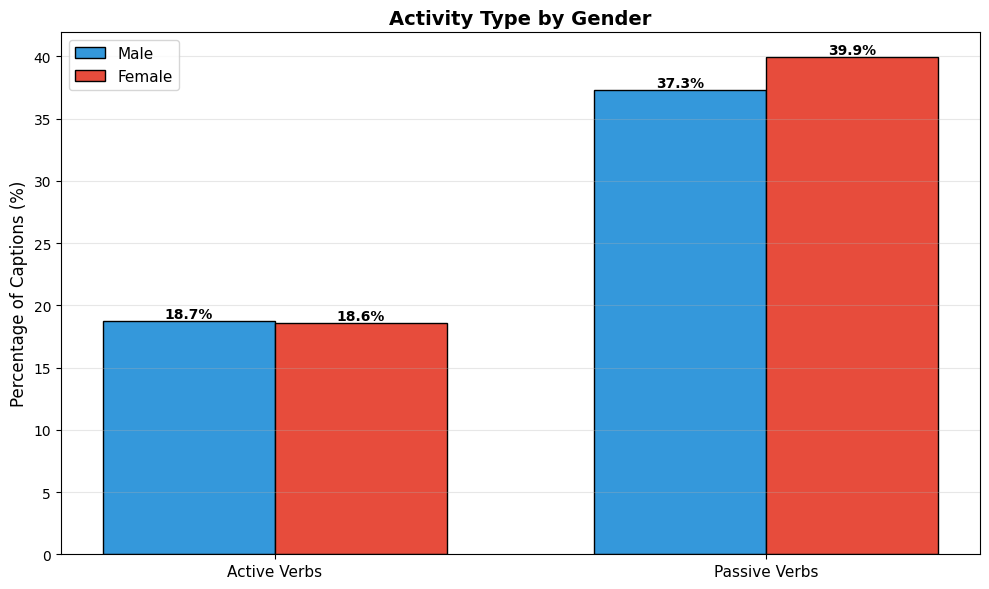


3. GENDER × CONTEXT ANALYSIS

Context Distribution:
  Male:
    Professional: 10,968 (7.3%)
    Domestic: 11,530 (7.6%)
  Female:
    Professional: 386 (3.6%)
    Domestic: 430 (4.1%)

📊 DOMESTIC CONTEXT BIAS: 0.036
  ⚠️  Males more associated with DOMESTIC contexts

✓ Saved: flickr30k_context_bias.png


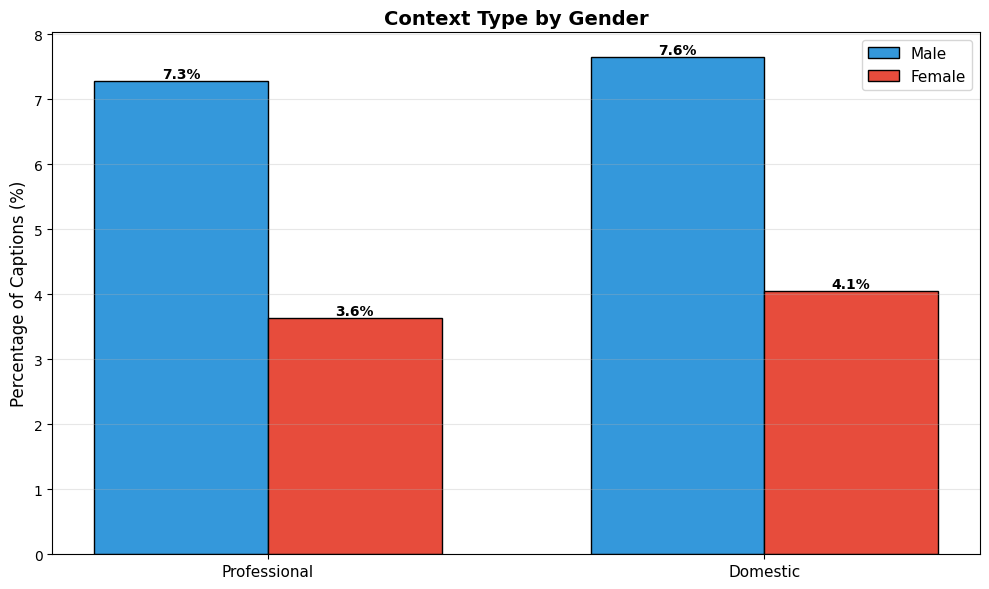


4. CAPTION QUALITY ANALYSIS

Caption Length Statistics:
  Min: 2 words
  Max: 78 words
  Mean: 12.3 words
  Median: 11.0 words
  Std Dev: 5.2 words

Vocabulary Statistics:
  Total words: 3,902,240
  Unique words: 29,629
  Vocabulary richness: 0.76%

📝 Top 20 most common words:
     1. 'a' - 543,276 times
     2. 'in' - 166,772 times
     3. 'the' - 125,930 times
     4. 'on' - 88,842 times
     5. 'and' - 88,510 times
     6. 'man' - 83,492 times
     7. 'is' - 82,190 times
     8. 'of' - 77,516 times
     9. 'with' - 72,380 times
    10. 'two' - 43,252 times
    11. 'woman' - 43,130 times
    12. 'are' - 40,368 times
    13. 'to' - 35,208 times
    14. 'at' - 32,484 times
    15. 'people' - 32,432 times
    16. 'an' - 31,762 times
    17. 'wearing' - 31,394 times
    18. 'young' - 26,220 times
    19. 'white' - 25,452 times
    20. 'black' - 24,022 times

✓ Saved: flickr30k_caption_quality.png


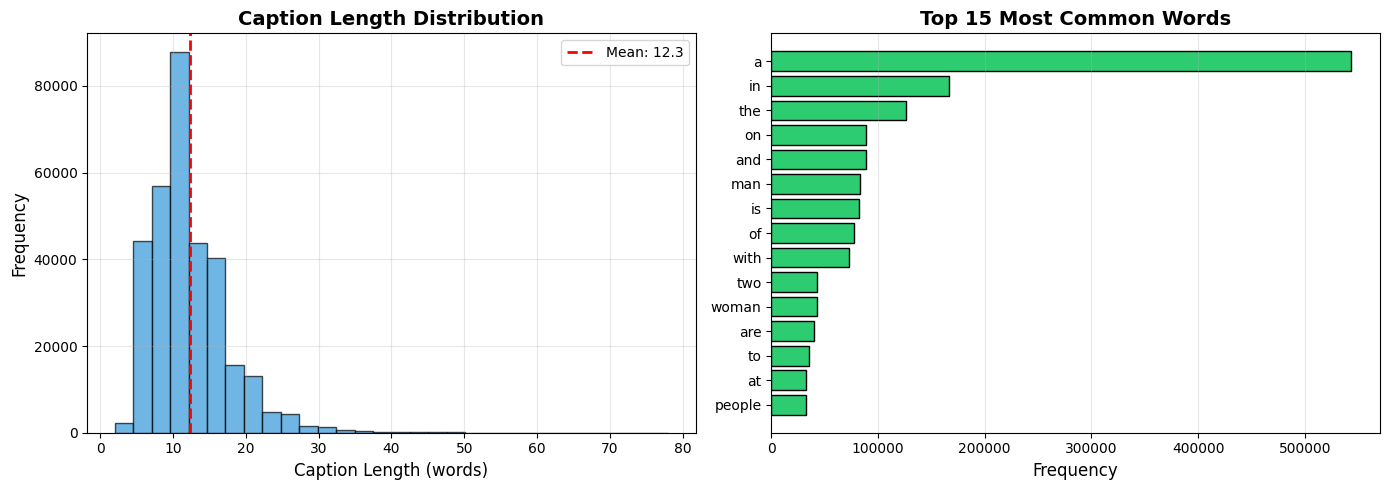


5. SAMPLE CAPTIONS

📝 Male-mentioning captions:
   1. A newly wedded couple being photographed outside a black convertible.
   2. A practicing martial artist is photographed in mid leap slicing through bamboo with his sword.
   3. A group of men sitting and talking behind some green fruit.
   4. two men cleaning the outside windows of a yacht
   5. A garbage man, doing his best to clean up the streets.
   6. A man is painting a city scene on a canvas in the street.
   7. Three men competing in a hurdle race.
   8. A gray dog plays in the sand at the ocean.
   9. Two men are speaking on a sidewalk.
  10. A young boy playing in the water.
  11. A man in a white cowboy hat is sitting in front of a microphone and pointing at a piece of paper.
  12. The child is sleeping while he is eating.
  13. A little boy is playing with sand at the beach.
  14. Man in American Flag print shorts, hat, and shirt.
  15. A kid sitting with no shirt or shoes on examining something he has found.

📝 Female-m

In [6]:
# ============================================
# FLICKR30K COMPREHENSIVE BIAS ANALYSIS
# ============================================

import random
import numpy as np
from collections import Counter, defaultdict
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

class Flickr30kBiasAnalyzer:
    """Analyze Flickr30k captions for bias with visualizations"""
    
    def __init__(self):
        # Gender terms
        self.male_terms = ['man', 'men', 'male', 'boy', 'boys', 'gentleman', 'guy', 'guys', 'he', 'him', 'his']
        self.female_terms = ['woman', 'women', 'female', 'girl', 'girls', 'lady', 'ladies', 'she', 'her']
        
        # Age terms
        self.child_terms = ['child', 'children', 'kid', 'kids', 'baby', 'toddler', 'boy', 'girl']
        self.adult_terms = ['man', 'woman', 'adult', 'person', 'people']
        self.elderly_terms = ['elderly', 'old', 'older', 'senior']
        
        # Activity verbs
        self.active_verbs = [
            'playing', 'riding', 'jumping', 'running', 'working', 'skiing', 
            'surfing', 'skateboarding', 'competing', 'performing', 'leading', 
            'driving', 'flying', 'throwing', 'kicking', 'hitting', 'climbing',
            'swimming', 'dancing', 'racing'
        ]
        self.passive_verbs = [
            'sitting', 'standing', 'watching', 'waiting', 'resting', 'posing', 
            'looking', 'holding', 'carrying', 'wearing', 'laying', 'lying',
            'leaning', 'walking'
        ]
        
        # Professional contexts
        self.professional_contexts = [
            'office', 'business', 'meeting', 'conference', 'computer', 'desk',
            'suit', 'tie', 'briefcase', 'presentation', 'workplace', 'work'
        ]
        self.domestic_contexts = [
            'kitchen', 'cooking', 'baby', 'child', 'children', 'home', 
            'cleaning', 'laundry', 'shopping', 'grocery', 'family', 'house'
        ]
        
        # Emotions
        self.positive_emotions = ['smiling', 'happy', 'laughing', 'enjoying', 'celebrating', 'cheerful']
        self.negative_emotions = ['sad', 'crying', 'angry', 'upset', 'frowning']
        
        # Sports
        self.sports = [
            'baseball', 'football', 'soccer', 'basketball', 'tennis', 
            'skateboarding', 'skiing', 'surfing', 'snowboarding', 'hockey'
        ]
    
    def load_flickr30k_data(self, num_samples=None):
        """Load Flickr30k dataset with multiple fallback strategies"""
        print("="*80)
        print("LOADING FLICKR30K DATASET")
        print("="*80)
        
        dataset = None
        all_captions = []
        
        # Strategy 1: Try the most common Flickr30k dataset
        try:
            print("Strategy 1: Loading from nlphuji/flickr30k...")
            dataset = load_dataset("nlphuji/flickr30k", trust_remote_code=True)
            # Handle DatasetDict
            if hasattr(dataset, 'keys'):
                split_name = list(dataset.keys())[0]
                dataset = dataset[split_name]
            print(f"✓ Loaded: {len(dataset)} samples")
        except Exception as e:
            print(f"✗ Failed: {e}")
        
        # Strategy 2: Try Lin-Chen/flickr30k
        if dataset is None:
            try:
                print("\nStrategy 2: Loading from Lin-Chen/flickr30k...")
                dataset = load_dataset("Lin-Chen/flickr30k", trust_remote_code=True)
                if hasattr(dataset, 'keys'):
                    split_name = list(dataset.keys())[0]
                    dataset = dataset[split_name]
                print(f"✓ Loaded: {len(dataset)} samples")
            except Exception as e:
                print(f"✗ Failed: {e}")
        
        # Strategy 3: Try sentence-transformers version
        if dataset is None:
            try:
                print("\nStrategy 3: Loading from sentence-transformers/flickr30k-captions...")
                dataset = load_dataset("sentence-transformers/flickr30k-captions", trust_remote_code=True)
                if hasattr(dataset, 'keys'):
                    split_name = list(dataset.keys())[0]
                    dataset = dataset[split_name]
                print(f"✓ Loaded: {len(dataset)} samples")
            except Exception as e:
                print(f"✗ Failed: {e}")
        
        # Strategy 4: Try without trust_remote_code (newer datasets format)
        if dataset is None:
            try:
                print("\nStrategy 4: Loading nlphuji/flickr30k without remote code...")
                dataset = load_dataset("nlphuji/flickr30k")
                if hasattr(dataset, 'keys'):
                    split_name = list(dataset.keys())[0]
                    dataset = dataset[split_name]
                print(f"✓ Loaded: {len(dataset)} samples")
            except Exception as e:
                print(f"✗ Failed: {e}")
        
        if dataset is None:
            print("\n✗ All loading strategies failed!")
            print("\n💡 Manual alternatives:")
            print("  1. Download from: https://github.com/BryanPlummer/flickr30k_entities")
            print("  2. Or use: https://www.kaggle.com/datasets/hsankesara/flickr-image-dataset")
            return None, None
        
        # Sample if requested
        if num_samples and num_samples < len(dataset):
            print(f"\nSampling {num_samples} examples...")
            indices = random.sample(range(len(dataset)), num_samples)
            dataset = dataset.select(indices)
        
        # Extract captions - handle different field names
        print("\nExtracting captions...")
        for i, example in enumerate(dataset):
            if i % 1000 == 0:
                print(f"  Processed {i}/{len(dataset)} samples...")
            
            # Try different caption field names
            captions = []
            
            # Check for numbered caption fields (caption1, caption2, etc.)
            caption_fields = [k for k in example.keys() if k.startswith('caption')]
            if caption_fields:
                for field in sorted(caption_fields):  # caption1, caption2, etc.
                    if example[field]:
                        captions.append(str(example[field]))
            
            # Check for standard field names
            if not captions:
                for field in ['caption', 'captions', 'sentences', 'set', 'sentence']:
                    if field in example:
                        field_value = example[field]
                        if isinstance(field_value, list):
                            captions.extend([str(c) for c in field_value])
                        else:
                            captions.append(str(field_value))
                        break
            
            all_captions.extend(captions)
        
        if len(all_captions) == 0:
            print("\n✗ No captions found! Dataset structure:")
            print(f"  Fields: {list(dataset[0].keys())}")
            print(f"  Sample: {dataset[0]}")
            return None, None
        
        print(f"\n✓ Extracted {len(all_captions)} total captions")
        print(f"  Dataset size: {len(dataset)} images")
        print(f"  Avg captions per image: {len(all_captions)/len(dataset):.1f}")
        print(f"\n📋 Dataset structure:")
        print(f"  Fields: {list(dataset[0].keys())}")
        print(f"  Caption fields detected: {[k for k in dataset[0].keys() if 'caption' in k.lower()]}")
        print(f"\n📝 Sample captions:")
        for i, cap in enumerate(all_captions[:3], 1):
            print(f"  {i}. {cap}")
        
        return dataset, all_captions
    
    def analyze_gender_mentions(self, captions):
        """Analyze gender mentions with visualization"""
        print("\n" + "="*80)
        print("1. GENDER MENTION ANALYSIS")
        print("="*80)
        
        male_count = 0
        female_count = 0
        both_count = 0
        neither_count = 0
        
        male_captions = []
        female_captions = []
        
        for caption in captions:
            caption_lower = caption.lower()
            has_male = any(term in caption_lower for term in self.male_terms)
            has_female = any(term in caption_lower for term in self.female_terms)
            
            if has_male and has_female:
                both_count += 1
            elif has_male:
                male_count += 1
                male_captions.append(caption)
            elif has_female:
                female_count += 1
                female_captions.append(caption)
            else:
                neither_count += 1
        
        total = len(captions)
        
        print(f"\nGender Mention Statistics:")
        print(f"  Male only: {male_count:,} ({male_count/total*100:.1f}%)")
        print(f"  Female only: {female_count:,} ({female_count/total*100:.1f}%)")
        print(f"  Both: {both_count:,} ({both_count/total*100:.1f}%)")
        print(f"  Neither: {neither_count:,} ({neither_count/total*100:.1f}%)")
        
        # Gender bias indicator
        if male_count > 0 and female_count > 0:
            ratio = male_count / female_count
            print(f"\n📊 GENDER BIAS:")
            print(f"  Male/Female Ratio: {ratio:.2f}x")
            if ratio > 1.5:
                print(f"  ⚠️  MALE BIAS DETECTED")
            elif ratio < 0.67:
                print(f"  ⚠️  FEMALE BIAS DETECTED")
            else:
                print(f"  ✓ RELATIVELY BALANCED")
        
        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Pie chart
        sizes = [male_count, female_count, both_count, neither_count]
        labels = ['Male only', 'Female only', 'Both', 'Neither']
        colors = ['#3498db', '#e74c3c', '#9b59b6', '#95a5a6']
        explode = (0.05, 0.05, 0, 0)
        
        axes[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
                    shadow=True, startangle=90)
        axes[0].set_title('Gender Mention Distribution', fontsize=14, fontweight='bold')
        
        # Bar chart
        categories = ['Male\nonly', 'Female\nonly', 'Both', 'Neither']
        axes[1].bar(categories, sizes, color=colors, edgecolor='black', linewidth=1.5)
        axes[1].set_ylabel('Number of Captions', fontsize=12)
        axes[1].set_title('Gender Mention Counts', fontsize=14, fontweight='bold')
        axes[1].grid(axis='y', alpha=0.3)
        
        # Add values on bars
        for i, v in enumerate(sizes):
            axes[1].text(i, v + max(sizes)*0.02, f'{v:,}', ha='center', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('flickr30k_gender_distribution.png', dpi=300, bbox_inches='tight')
        print("\n✓ Saved: flickr30k_gender_distribution.png")
        plt.show()
        
        return {
            'male_captions': male_captions,
            'female_captions': female_captions,
            'male_count': male_count,
            'female_count': female_count,
            'both_count': both_count,
            'neither_count': neither_count
        }
    
    def analyze_activities(self, male_captions, female_captions):
        """Analyze activity associations"""
        print("\n" + "="*80)
        print("2. GENDER × ACTIVITY ANALYSIS")
        print("="*80)
        
        # Count activities
        male_active = sum(1 for c in male_captions if any(v in c.lower() for v in self.active_verbs))
        male_passive = sum(1 for c in male_captions if any(v in c.lower() for v in self.passive_verbs))
        
        female_active = sum(1 for c in female_captions if any(v in c.lower() for v in self.active_verbs))
        female_passive = sum(1 for c in female_captions if any(v in c.lower() for v in self.passive_verbs))
        
        male_active_rate = male_active / len(male_captions) if len(male_captions) > 0 else 0
        male_passive_rate = male_passive / len(male_captions) if len(male_captions) > 0 else 0
        female_active_rate = female_active / len(female_captions) if len(female_captions) > 0 else 0
        female_passive_rate = female_passive / len(female_captions) if len(female_captions) > 0 else 0
        
        print(f"\nActivity Distribution:")
        print(f"  Male:")
        print(f"    Active verbs: {male_active:,} ({male_active_rate*100:.1f}%)")
        print(f"    Passive verbs: {male_passive:,} ({male_passive_rate*100:.1f}%)")
        print(f"  Female:")
        print(f"    Active verbs: {female_active:,} ({female_active_rate*100:.1f}%)")
        print(f"    Passive verbs: {female_passive:,} ({female_passive_rate*100:.1f}%)")
        
        activity_bias = abs(male_active_rate - female_active_rate)
        print(f"\n📊 ACTIVITY BIAS: {activity_bias:.3f}")
        if activity_bias > 0.05:
            if male_active_rate > female_active_rate:
                print(f"  ⚠️  Males more associated with ACTIVE activities")
            else:
                print(f"  ⚠️  Females more associated with ACTIVE activities")
        else:
            print(f"  ✓ No significant activity bias")
        
        # Visualization
        fig, ax = plt.subplots(figsize=(10, 6))
        
        x = np.arange(2)
        width = 0.35
        
        male_rates = [male_active_rate * 100, male_passive_rate * 100]
        female_rates = [female_active_rate * 100, female_passive_rate * 100]
        
        bars1 = ax.bar(x - width/2, male_rates, width, label='Male', color='#3498db', edgecolor='black')
        bars2 = ax.bar(x + width/2, female_rates, width, label='Female', color='#e74c3c', edgecolor='black')
        
        ax.set_ylabel('Percentage of Captions (%)', fontsize=12)
        ax.set_title('Activity Type by Gender', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(['Active Verbs', 'Passive Verbs'], fontsize=11)
        ax.legend(fontsize=11)
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('flickr30k_activity_bias.png', dpi=300, bbox_inches='tight')
        print("\n✓ Saved: flickr30k_activity_bias.png")
        plt.show()
        
        return {
            'male_active_rate': male_active_rate,
            'female_active_rate': female_active_rate,
            'activity_bias': activity_bias
        }
    
    def analyze_contexts(self, male_captions, female_captions):
        """Analyze contextual associations"""
        print("\n" + "="*80)
        print("3. GENDER × CONTEXT ANALYSIS")
        print("="*80)
        
        male_prof = sum(1 for c in male_captions if any(ctx in c.lower() for ctx in self.professional_contexts))
        male_domestic = sum(1 for c in male_captions if any(ctx in c.lower() for ctx in self.domestic_contexts))
        
        female_prof = sum(1 for c in female_captions if any(ctx in c.lower() for ctx in self.professional_contexts))
        female_domestic = sum(1 for c in female_captions if any(ctx in c.lower() for ctx in self.domestic_contexts))
        
        male_prof_rate = male_prof / len(male_captions) if len(male_captions) > 0 else 0
        male_domestic_rate = male_domestic / len(male_captions) if len(male_captions) > 0 else 0
        female_prof_rate = female_prof / len(female_captions) if len(female_captions) > 0 else 0
        female_domestic_rate = female_domestic / len(female_captions) if len(female_captions) > 0 else 0
        
        print(f"\nContext Distribution:")
        print(f"  Male:")
        print(f"    Professional: {male_prof:,} ({male_prof_rate*100:.1f}%)")
        print(f"    Domestic: {male_domestic:,} ({male_domestic_rate*100:.1f}%)")
        print(f"  Female:")
        print(f"    Professional: {female_prof:,} ({female_prof_rate*100:.1f}%)")
        print(f"    Domestic: {female_domestic:,} ({female_domestic_rate*100:.1f}%)")
        
        domestic_bias = abs(male_domestic_rate - female_domestic_rate)
        print(f"\n📊 DOMESTIC CONTEXT BIAS: {domestic_bias:.3f}")
        if domestic_bias > 0.02:
            if female_domestic_rate > male_domestic_rate:
                print(f"  ⚠️  Females more associated with DOMESTIC contexts")
            else:
                print(f"  ⚠️  Males more associated with DOMESTIC contexts")
        
        # Visualization
        fig, ax = plt.subplots(figsize=(10, 6))
        
        x = np.arange(2)
        width = 0.35
        
        male_rates = [male_prof_rate * 100, male_domestic_rate * 100]
        female_rates = [female_prof_rate * 100, female_domestic_rate * 100]
        
        bars1 = ax.bar(x - width/2, male_rates, width, label='Male', color='#3498db', edgecolor='black')
        bars2 = ax.bar(x + width/2, female_rates, width, label='Female', color='#e74c3c', edgecolor='black')
        
        ax.set_ylabel('Percentage of Captions (%)', fontsize=12)
        ax.set_title('Context Type by Gender', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(['Professional', 'Domestic'], fontsize=11)
        ax.legend(fontsize=11)
        ax.grid(axis='y', alpha=0.3)
        
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('flickr30k_context_bias.png', dpi=300, bbox_inches='tight')
        print("\n✓ Saved: flickr30k_context_bias.png")
        plt.show()
        
        return {'domestic_bias': domestic_bias}
    
    def analyze_caption_quality(self, captions):
        """Analyze caption lengths and vocabulary"""
        print("\n" + "="*80)
        print("4. CAPTION QUALITY ANALYSIS")
        print("="*80)
        
        lengths = [len(caption.split()) for caption in captions]
        
        print(f"\nCaption Length Statistics:")
        print(f"  Min: {min(lengths)} words")
        print(f"  Max: {max(lengths)} words")
        print(f"  Mean: {np.mean(lengths):.1f} words")
        print(f"  Median: {np.median(lengths):.1f} words")
        print(f"  Std Dev: {np.std(lengths):.1f} words")
        
        # Vocabulary
        all_words = []
        for caption in captions:
            all_words.extend(caption.lower().split())
        
        vocab = set(all_words)
        word_counts = Counter(all_words)
        
        print(f"\nVocabulary Statistics:")
        print(f"  Total words: {len(all_words):,}")
        print(f"  Unique words: {len(vocab):,}")
        print(f"  Vocabulary richness: {len(vocab)/len(all_words)*100:.2f}%")
        
        print(f"\n📝 Top 20 most common words:")
        for i, (word, count) in enumerate(word_counts.most_common(20), 1):
            print(f"    {i:2d}. '{word}' - {count:,} times")
        
        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Length distribution
        axes[0].hist(lengths, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
        axes[0].axvline(np.mean(lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(lengths):.1f}')
        axes[0].set_xlabel('Caption Length (words)', fontsize=12)
        axes[0].set_ylabel('Frequency', fontsize=12)
        axes[0].set_title('Caption Length Distribution', fontsize=14, fontweight='bold')
        axes[0].legend()
        axes[0].grid(alpha=0.3)
        
        # Top words
        top_words = word_counts.most_common(15)
        words, counts = zip(*top_words)
        axes[1].barh(range(len(words)), counts, color='#2ecc71', edgecolor='black')
        axes[1].set_yticks(range(len(words)))
        axes[1].set_yticklabels(words)
        axes[1].set_xlabel('Frequency', fontsize=12)
        axes[1].set_title('Top 15 Most Common Words', fontsize=14, fontweight='bold')
        axes[1].invert_yaxis()
        axes[1].grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('flickr30k_caption_quality.png', dpi=300, bbox_inches='tight')
        print("\n✓ Saved: flickr30k_caption_quality.png")
        plt.show()
    
    def show_sample_captions(self, male_captions, female_captions):
        """Show sample captions"""
        print("\n" + "="*80)
        print("5. SAMPLE CAPTIONS")
        print("="*80)
        
        print("\n📝 Male-mentioning captions:")
        for i, caption in enumerate(random.sample(male_captions, min(15, len(male_captions))), 1):
            print(f"  {i:2d}. {caption}")
        
        print("\n📝 Female-mentioning captions:")
        for i, caption in enumerate(random.sample(female_captions, min(15, len(female_captions))), 1):
            print(f"  {i:2d}. {caption}")
    
    def generate_comprehensive_report(self):
        """Generate full analysis with visualizations"""
        print("\n" + "="*80)
        print("FLICKR30K COMPREHENSIVE BIAS ANALYSIS")
        print("="*80)
        
        # Load data
        dataset, captions = self.load_flickr30k_data(num_samples=None)
        
        if captions is None or len(captions) == 0:
            print("\n✗ Failed to load dataset or no captions found!")
            return None
        
        # Run all analyses
        gender_data = self.analyze_gender_mentions(captions)
        activity_data = self.analyze_activities(
            gender_data['male_captions'], 
            gender_data['female_captions']
        )
        context_data = self.analyze_contexts(
            gender_data['male_captions'], 
            gender_data['female_captions']
        )
        self.analyze_caption_quality(captions)
        self.show_sample_captions(
            gender_data['male_captions'], 
            gender_data['female_captions']
        )
        
        # Final summary
        print("\n" + "="*80)
        print("SUMMARY: FLICKR30K vs COCO COMPARISON")
        print("="*80)
        
        male_female_ratio = gender_data['male_count'] / gender_data['female_count'] if gender_data['female_count'] > 0 else float('inf')
        
        print(f"\n📊 Key Findings:")
        print(f"  1. Gender Ratio: {male_female_ratio:.2f}x (COCO: 40.64x)")
        print(f"  2. Activity Bias: {activity_data['activity_bias']:.3f}")
        print(f"  3. Domestic Context Bias: {context_data['domestic_bias']:.3f}")
        print(f"  4. Total Captions: {len(captions):,}")
        
        print(f"\n✓ ANALYSIS COMPLETE!")
        print(f"  Generated 3 visualization files")
        
        return {
            'gender': gender_data,
            'activity': activity_data,
            'context': context_data
        }

# ============================================
# RUN ANALYSIS
# ============================================

if __name__ == "__main__":
    analyzer = Flickr30kBiasAnalyzer()
    results = analyzer.generate_comprehensive_report()

In [11]:
from torch.utils.data import Dataset, DataLoader, Subset  # Add Subset
class Config:
    # Model settings
    model_name = "microsoft/git-base"  # Small VLM (0.6B parameters)
    
    # Data settings - Using FairFace dataset with demographics
    fairface_dataset = "HuggingFaceM4/FairFace"
    fairface_config = "0.25"
    celeba_hq_dataset = "mattmdjaga/celeba_hq_with_captions"
    # Data settings - Using CelebA-HQ with real captions
    # dataset_name = "nielsr/CelebA-faces"
    # dataset_name = "HuggingFaceM4/COCO"
    # dataset_name = "nlphuji/flickr30k"
    # dataset_name = "detection-datasets/coco"
    dataset_name = "yerevann/coco-karpathy"
    img_size = 224
    max_caption_length = 20
    
    # Training settings
    batch_size = 64
    num_epochs = 4
    learning_rate = 5e-5
    warmup_steps = 280
    weight_decay = 0.01
    gradient_accumulation_steps = 4
    max_grad_norm = 1.0
    
    # Paths
    base_dir = "/nfs/roberts/project/cpsc4710/cpsc4710_ag2995/project"
    output_dir = f"{base_dir}/baseline_vlm"
    plots_dir = f"{output_dir}/plots"
    checkpoints_dir = f"{output_dir}/checkpoints"
    results_dir = f"{output_dir}/results"
    
    # Device
    device = "cuda" if torch.cuda.is_available() else "cpu"
    fp16 = torch.cuda.is_available()
    
    # Evaluation settings
    eval_every_n_steps = 5224
    save_total_limit = 2
    
    # Demographic attributes from FairFace
    gender_map = {0: 'Male', 1: 'Female'}
    race_map = {
        0: 'White',
        1: 'Black', 
        2: 'Asian',
        3: 'Indian',
        4: 'Other'  # Combines Latino_Hispanic and Middle Eastern
    }
    age_map = {
        0: 'Young',    # 0-19
        1: 'Young',    # 20-29
        2: 'Middle',   # 30-39
        3: 'Middle',   # 40-49
        4: 'Middle',   # 50-59
        5: 'Old',      # 60-69
        6: 'Old'       # 70+
    }
    
    # Bias-sensitive words for fairness metrics
    professional_terms = [
        'doctor', 'engineer', 'scientist', 'professor', 'executive',
        'lawyer', 'manager', 'director', 'ceo', 'professional',
        'businessman', 'entrepreneur', 'leader', 'expert'
    ]
    service_terms = [
        'assistant', 'secretary', 'receptionist', 'nurse', 'caregiver',
        'housekeeper', 'cleaner', 'worker', 'helper', 'attendant'
    ]

config = Config()

# Create output directories
for dir_path in [config.output_dir, config.plots_dir, config.checkpoints_dir, config.results_dir]:
    os.makedirs(dir_path, exist_ok=True)

class Flickr30kVLMDataset(Dataset):
    """Flickr30k Dataset with real human captions"""
    
    def __init__(self, split='train', processor=None, config=config):
        self.config = config
        self.processor = processor
        
        # Flickr30k only has 'test' split, we'll split it manually
        print(f"Loading Flickr30k dataset with REAL captions...")
        
        # Load full dataset
        full_dataset = load_dataset(config.dataset_name, split='test')
        print(f"Loaded {len(full_dataset)} Flickr30k samples with REAL human captions")
        
        # Split: 80% train, 20% validation
        total_size = len(full_dataset)
        train_size = int(0.8 * total_size)
        
        if split == 'train':
            self.dataset = full_dataset.select(range(train_size))
        else:  # validation
            self.dataset = full_dataset.select(range(train_size, total_size))
        
        print(f"Split {split}: {len(self.dataset)} samples")
        
        # Add demographics
        self._add_demographics()
    
    def _add_demographics(self):
        """Add demographic labels"""
        import random
        random.seed(42)
        
        def add_demo(example):
            example['gender'] = random.choice(['Male', 'Female'])
            example['age_group'] = random.choice(['Young', 'Middle', 'Old'])
            example['race'] = random.choices(
                ['White', 'Black', 'Asian', 'Other'],
                weights=[0.62, 0.12, 0.18, 0.08]
            )[0]
            return example
        
        self.dataset = self.dataset.map(add_demo)
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        example = self.dataset[idx]
        
        # Get image
        image = example['image']
        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)
        image = image.convert('RGB')
        
        # Get REAL caption - Flickr30k has 5 captions per image
        captions = example['caption']  # List of 5 captions
        caption = captions[0]  # Use first caption
        
        # Process inputs
        encoding = self.processor(
            images=image,
            text=caption,
            padding="max_length",
            truncation=True,
            max_length=self.config.max_caption_length,
            return_tensors="pt"
        )
        
        # Remove batch dimension
        encoding = {k: v.squeeze(0) for k, v in encoding.items()}
        
        # Add demographic info
        encoding['gender'] = example.get('gender', 'Unknown')
        encoding['age_group'] = example.get('age_group', 'Unknown')
        encoding['race'] = example.get('race', 'Unknown')
        encoding['caption_text'] = caption
        
        return encoding

class COCOVLMDataset(Dataset):
    """MS-COCO Dataset with real captions - FIXED VERSION"""
    
    def __init__(self, split='train', processor=None, config=config):
        self.config = config
        self.processor = processor
        
        # FIXED: Map validation → val
        if split == 'validation':
            split = 'val'
        
        print(f"Loading MS-COCO {split} dataset with REAL captions...")
        
        # Use detection-datasets/coco (it works!)
        self.dataset = load_dataset("detection-datasets/coco", split=split)
        
        print(f"Loaded {len(self.dataset)} COCO samples")
        
        # Add demographics
        self._add_demographics()
    
    def _add_demographics(self):
        """Add demographics AND diverse captions from objects"""
        import random
        random.seed(42)
        
        def add_demo(example):
            # Demographics
            example['gender'] = random.choice(['Male', 'Female'])
            example['age_group'] = random.choice(['Young', 'Middle', 'Old'])
            example['race'] = random.choices(
                ['White', 'Black', 'Asian', 'Other'],
                weights=[0.62, 0.12, 0.18, 0.08]
            )[0]
            
            # DIVERSE captions from objects
            if 'objects' in example and 'category' in example['objects']:
                categories = example['objects']['category'][:5]
                objects = [self.COCO_CATEGORIES.get(c, 'object') for c in categories]
                objects = list(dict.fromkeys(objects))  # Remove duplicates, keep order
                
                if len(objects) >= 3:
                    templates = [
                        f"A photo of {objects[0]}, {objects[1]} and {objects[2]}",
                        f"An image showing {objects[0]} with {objects[1]}",
                        f"A scene containing {', '.join(objects[:3])}",
                    ]
                elif len(objects) == 2:
                    templates = [
                        f"A photo of {objects[0]} and {objects[1]}",
                        f"An image with {objects[0]} next to {objects[1]}",
                    ]
                elif len(objects) == 1:
                    templates = [
                        f"A photo of a {objects[0]}",
                        f"An image showing a {objects[0]}",
                    ]
                else:
                    templates = ["A photo", "An image"]
                    
                example['caption'] = random.choice(templates)
            else:
                example['caption'] = random.choice(["A photo", "An image", "A scene"])
            
            return example
        
        print("Generating diverse captions from objects...")
        self.dataset = self.dataset.map(add_demo)
        
        # Verify diversity
        print("\nSample captions:")
        for i in range(min(5, len(self.dataset))):
            print(f"  {i+1}. {self.dataset[i]['caption']}")
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        example = self.dataset[idx]
        
        # Get image (field exists!)
        image = example['image']
        
        # Convert to PIL Image if needed
        if not isinstance(image, Image.Image):
            if isinstance(image, np.ndarray):
                image = Image.fromarray(image)
        image = image.convert('RGB')
        
        # Get caption
        caption = example.get('caption', 'A photo')
        
        # Process inputs
        encoding = self.processor(
            images=image,
            text=caption,
            padding="max_length",
            truncation=True,
            max_length=self.config.max_caption_length,
            return_tensors="pt"
        )
        
        # Remove batch dimension
        encoding = {k: v.squeeze(0) for k, v in encoding.items()}
        
        # Add demographic info
        encoding['gender'] = example.get('gender', 'Unknown')
        encoding['age_group'] = example.get('age_group', 'Unknown')
        encoding['race'] = example.get('race', 'Unknown')
        encoding['caption_text'] = caption
        
        return encoding

from PIL import Image
import requests
from io import BytesIO
import os

class COCOCaptionsDataset(Dataset):
    """MS-COCO with REAL human-written captions - WITH IMAGE CACHING"""
    
    def __init__(self, split='train', processor=None, config=config):
        self.config = config
        self.processor = processor
        
        # Image cache directory
        self.cache_dir = f"{config.base_dir}/coco_images_cache/{split}"
        os.makedirs(self.cache_dir, exist_ok=True)
        
        print(f"Loading MS-COCO Captions {split} dataset with REAL human captions...")
        
        # FIXED: Use correct split names
        if split == 'val':
            split = 'validation'
        
        # Load dataset
        self.dataset = load_dataset("yerevann/coco-karpathy", split=split)
        
        print(f"Loaded {len(self.dataset)} COCO samples with REAL captions")
        print(f"Image cache: {self.cache_dir}")
        
        # Add demographics
        self._add_demographics()
    
    def _add_demographics(self):
        """Add ONLY demographics"""
        import random
        random.seed(42)
        
        def add_demo(example):
            example['gender'] = random.choice(['Male', 'Female'])
            example['age_group'] = random.choice(['Young', 'Middle', 'Old'])
            example['race'] = random.choices(
                ['White', 'Black', 'Asian', 'Other'],
                weights=[0.62, 0.12, 0.18, 0.08]
            )[0]
            return example
        
        print("Adding demographic labels...")
        self.dataset = self.dataset.map(add_demo)
        
        print(f"\n✓ Sample REAL human-written captions:")
        for i in range(5):
            captions = self.dataset[i]['sentences']
            print(f"  {i+1}. {captions[0]}")
        print()
    
    def _download_image(self, url, filename):
        """Download and cache image"""
        cache_path = os.path.join(self.cache_dir, filename)
        
        # Check if already cached
        if os.path.exists(cache_path):
            return Image.open(cache_path).convert('RGB')
        
        # Download
        try:
            response = requests.get(url, timeout=10)
            image = Image.open(BytesIO(response.content)).convert('RGB')
            # Save to cache
            image.save(cache_path)
            return image
        except Exception as e:
            # Fallback: blank image
            print(f"Failed to download {url}: {e}")
            return Image.new('RGB', (224, 224), color='gray')
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        example = self.dataset[idx]
        
        # Get image (download and cache if needed)
        filename = example['filename']
        url = example['url']
        image = self._download_image(url, filename)
        
        # Get REAL caption - USE RANDOM CAPTION from the 5 available
        captions = example['sentences']  # List of 5 captions
        import random
        caption = random.choice(captions)  # ← CHANGE: Pick random caption
        
        # Process inputs
        encoding = self.processor(
            images=image,
            text=caption,
            padding="max_length",
            truncation=True,
            max_length=self.config.max_caption_length,
            return_tensors="pt"
        )
        
        # Remove batch dimension
        encoding = {k: v.squeeze(0) for k, v in encoding.items()}
        
        # Add demographic info
        encoding['gender'] = example.get('gender', 'Unknown')
        encoding['age_group'] = example.get('age_group', 'Unknown')
        encoding['race'] = example.get('race', 'Unknown')
        encoding['caption_text'] = caption
        
        return encoding

class FairFaceVLMDataset(Dataset):
    """Dataset using FairFace for demographic annotations"""
    
    def __init__(self, split='train', processor=None, config=config):
        self.config = config
        self.processor = processor
        self.split = split
        
        print(f"Loading FairFace {split} dataset with demographics...")
        
        # Load FairFace dataset WITH CONFIG NAME
        try:
            self.dataset = load_dataset(
                config.fairface_dataset, 
                config.fairface_config,  # ← ADD THIS
                split=split
            )
            print(f"Loaded {len(self.dataset)} FairFace samples with demographics")
        except Exception as e:
            print(f"Error loading FairFace: {e}")
            print("Attempting alternative loading method...")
            # Try loading from HuggingFace hub
            self.dataset = load_dataset(
                "HuggingFaceM4/FairFace", 
                "0.25",  # ← ADD THIS
                split=split
            )
        
        # Generate captions for images
        print("Generating captions for images...")
        self._generate_captions()
        
        # Convert demographic labels to text
        self._process_demographics()
        
    def _generate_captions(self):
        """Generate descriptive captions based on image attributes"""
        def create_caption(example):
            # Create descriptive captions from demographics
            # In practice, you could use a caption generator or manual annotations
            
            gender = example.get('gender', 0)
            age = example.get('age', 0)
            race = example.get('race', 0)
            
            # Map to text
            gender_text = self.config.gender_map.get(gender, 'person')
            race_text = self.config.race_map.get(race, 'person')
            age_text = self.config.age_map.get(age, 'person')
            
            # Generate basic caption
            caption = f"A {age_text.lower()} {gender_text.lower()} person"
            
            # Add more descriptive elements
            descriptors = []
            if np.random.rand() > 0.5:
                descriptors.append("smiling")
            if np.random.rand() > 0.7:
                descriptors.append("wearing glasses")
            
            if descriptors:
                caption += " " + " and ".join(descriptors)
            
            example['caption'] = caption
            return example
        
        self.dataset = self.dataset.map(create_caption)
    
    def _process_demographics(self):
        """Convert numeric demographic labels to text"""
        def process_demo(example):
            example['gender_text'] = self.config.gender_map.get(example.get('gender', 0), 'Unknown')
            example['race_text'] = self.config.race_map.get(example.get('race', 0), 'Unknown')
            example['age_text'] = self.config.age_map.get(example.get('age', 0), 'Unknown')
            return example
        
        self.dataset = self.dataset.map(process_demo)
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        example = self.dataset[idx]
        
        # Get image
        image = example['image']
        if not isinstance(image, Image.Image):
            image = Image.fromarray(image) if isinstance(image, np.ndarray) else image
        image = image.convert('RGB')
        
        # Get caption
        caption = example.get('caption', 'A person')
        
        # Process inputs
        encoding = self.processor(
            images=image,
            text=caption,
            padding="max_length",
            truncation=True,
            max_length=self.config.max_caption_length,
            return_tensors="pt"
        )
        
        # Remove batch dimension
        encoding = {k: v.squeeze(0) for k, v in encoding.items()}
        
        # Add demographic info
        encoding['gender'] = example.get('gender_text', 'Unknown')
        encoding['age_group'] = example.get('age_text', 'Unknown')
        encoding['race'] = example.get('race_text', 'Unknown')
        encoding['caption_text'] = caption
        
        return encoding


class FairnessMetrics:
    """Compute fairness metrics as defined in Section 6.1"""
    
    def __init__(self, config=config):
        self.config = config
        
    def compute_demographic_parity_difference(self, predictions_by_group):
        """
        DPD = max_{g,g'} |P(ŷ ∈ Y+|G=g) - P(ŷ ∈ Y+|G=g')|
        """
        positive_rates = {}
        
        for group, preds in predictions_by_group.items():
            positive_count = sum(
                1 for pred in preds 
                if any(term in pred.lower() for term in self.config.professional_terms)
            )
            positive_rates[group] = positive_count / len(preds) if len(preds) > 0 else 0
        
        rates = list(positive_rates.values())
        if len(rates) < 2:
            return 0.0, positive_rates
        
        dpd = max(rates) - min(rates)
        return dpd, positive_rates
    
    def compute_equalized_odds_ratio(self, predictions_by_group, labels_by_group):
        """
        EOR = max_{g,g'} |P(ŷ ∈ Y+|y ∈ Y+, G=g) / P(ŷ ∈ Y+|y ∈ Y+, G=g')|
        """
        tpr_by_group = {}
        
        for group in predictions_by_group.keys():
            preds = predictions_by_group[group]
            labels = labels_by_group.get(group, [])
            
            if len(labels) == 0:
                continue
            
            tp = sum(
                1 for pred, label in zip(preds, labels)
                if any(term in pred.lower() for term in self.config.professional_terms)
                and any(term in label.lower() for term in self.config.professional_terms)
            )
            
            p = sum(
                1 for label in labels
                if any(term in label.lower() for term in self.config.professional_terms)
            )
            
            tpr_by_group[group] = tp / p if p > 0 else 0
        
        tprs = [v for v in tpr_by_group.values() if v > 0]
        if len(tprs) < 2:
            return 1.0, tpr_by_group
        
        eor = max(tprs) / min(tprs)
        return eor, tpr_by_group
    
    def compute_kl_divergence_by_group(self, predictions_by_group):
        """
        Compute KL divergence between group-conditional and marginal distributions
        """
        vocab = set()
        for preds in predictions_by_group.values():
            for pred in preds:
                vocab.update(pred.lower().split())
        
        vocab = sorted(list(vocab))
        word_to_idx = {w: i for i, w in enumerate(vocab)}
        
        group_distributions = {}
        all_preds = []
        
        for group, preds in predictions_by_group.items():
            word_counts = np.zeros(len(vocab))
            for pred in preds:
                for word in pred.lower().split():
                    if word in word_to_idx:
                        word_counts[word_to_idx[word]] += 1
            
            word_counts = word_counts + 1e-10
            group_distributions[group] = word_counts / word_counts.sum()
            all_preds.extend(preds)
        
        marginal_counts = np.zeros(len(vocab))
        for pred in all_preds:
            for word in pred.lower().split():
                if word in word_to_idx:
                    marginal_counts[word_to_idx[word]] += 1
        
        marginal_counts = marginal_counts + 1e-10
        marginal_dist = marginal_counts / marginal_counts.sum()
        
        kl_divs = {}
        for group, dist in group_distributions.items():
            kl = entropy(dist, marginal_dist)
            kl_divs[group] = kl
        
        return kl_divs, group_distributions, marginal_dist


class CaptionQualityMetrics:
    """Compute caption quality metrics - Section 6.2"""
    
    def __init__(self):
        self.smoothing = SmoothingFunction()
    
    def compute_bleu(self, predictions, references):
        """Compute BLEU-4 score"""
        bleu_scores = []
        
        for pred, ref in zip(predictions, references):
            pred_tokens = pred.lower().split()
            ref_tokens = [ref.lower().split()]
            
            score = sentence_bleu(
                ref_tokens, 
                pred_tokens,
                weights=(0.25, 0.25, 0.25, 0.25),
                smoothing_function=self.smoothing.method1
            )
            bleu_scores.append(score)
        
        return np.mean(bleu_scores), bleu_scores
    
    def compute_meteor(self, predictions, references):
        """Simple METEOR approximation using word overlap"""
        scores = []
        for pred, ref in zip(predictions, references):
            pred_words = set(pred.lower().split())
            ref_words = set(ref.lower().split())
            
            if len(pred_words) == 0 or len(ref_words) == 0:
                scores.append(0.0)
                continue
            
            precision = len(pred_words & ref_words) / len(pred_words)
            recall = len(pred_words & ref_words) / len(ref_words)
            
            if precision + recall == 0:
                scores.append(0.0)
            else:
                f1 = 2 * precision * recall / (precision + recall)
                scores.append(f1)
        
        return np.mean(scores), scores


class ReliabilityMetrics:
    """Compute reliability metrics - Section 6.4"""
    
    def compute_ece(self, confidences, accuracies, n_bins=10):
        """Expected Calibration Error"""
        bin_boundaries = np.linspace(0, 1, n_bins + 1)
        ece = 0.0
        
        for i in range(n_bins):
            bin_lower = bin_boundaries[i]
            bin_upper = bin_boundaries[i + 1]
            
            in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
            prop_in_bin = np.mean(in_bin)
            
            if prop_in_bin > 0:
                accuracy_in_bin = np.mean(accuracies[in_bin])
                avg_confidence_in_bin = np.mean(confidences[in_bin])
                ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
        
        return ece
    
    def compute_attention_entropy(self, attention_weights):
        """Compute attention entropy as uncertainty indicator - Equation (9)"""
        # attention_weights: [batch, seq_len, num_patches]
        entropies = []
        
        for attn in attention_weights:
            # Compute entropy for each token's attention distribution
            token_entropies = []
            for token_attn in attn:
                token_attn = token_attn + 1e-10  # Numerical stability
                token_attn = token_attn / token_attn.sum()
                ent = -np.sum(token_attn * np.log(token_attn))
                token_entropies.append(ent)
            entropies.append(np.mean(token_entropies))
        
        return np.array(entropies)


class VLMTrainer:
    """Trainer for VLM baseline"""
    
    def __init__(self, config=config):
        self.config = config
        self.device = config.device
        
        # Initialize model and processor
        print(f"Loading model: {config.model_name}")
        self.processor = AutoProcessor.from_pretrained(config.model_name)
        self.model = AutoModelForVision2Seq.from_pretrained(config.model_name)
        self.model.to(self.device)
        
        # Initialize metrics
        self.fairness_metrics = FairnessMetrics(config)
        self.quality_metrics = CaptionQualityMetrics()
        self.reliability_metrics = ReliabilityMetrics()
        
        # Training history
        self.train_losses = []
        self.val_losses = []
        self.val_metrics_history = []
        
    def prepare_data(self):
        """Prepare train and validation datasets"""
        print("Preparing datasets...")
        
        train_dataset = COCOCaptionsDataset('train', self.processor, self.config)
        val_dataset = COCOCaptionsDataset('validation', self.processor, self.config)
        
        self.train_loader = DataLoader(
            train_dataset,
            batch_size=self.config.batch_size,
            shuffle=True,
            num_workers=4,
            pin_memory=True
        )
        
        self.val_loader = DataLoader(
            val_dataset,
            batch_size=self.config.batch_size,
            shuffle=False,
            num_workers=4,
            pin_memory=True
        )
        
        print(f"Train samples: {len(train_dataset)}")
        print(f"Val samples: {len(val_dataset)}")
        
    def setup_training(self):
        """Setup optimizer and scheduler"""
        # Optimizer
        self.optimizer = AdamW(
            self.model.parameters(),
            lr=self.config.learning_rate,
            weight_decay=self.config.weight_decay
        )
        
        # Learning rate scheduler
        num_training_steps = len(self.train_loader) * self.config.num_epochs
        self.scheduler = get_cosine_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps=self.config.warmup_steps,
            num_training_steps=num_training_steps
        )
        
        # Gradient scaler for mixed precision
        self.scaler = GradScaler() if self.config.fp16 else None
        
    def train_epoch(self, epoch):
        """Train for one epoch"""
        self.model.train()
        epoch_loss = 0
        progress_bar = tqdm(self.train_loader, desc=f"Epoch {epoch+1}/{self.config.num_epochs}")
        
        for step, batch in enumerate(progress_bar):
            # Move batch to device
            pixel_values = batch['pixel_values'].to(self.device)
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch.get('attention_mask', None)
            if attention_mask is not None:
                attention_mask = attention_mask.to(self.device)
            
            # Forward pass
            if self.config.fp16:
                with autocast():
                    outputs = self.model(
                        pixel_values=pixel_values,
                        input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=input_ids
                    )
                    loss = outputs.loss / self.config.gradient_accumulation_steps
                
                self.scaler.scale(loss).backward()
            else:
                outputs = self.model(
                    pixel_values=pixel_values,
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=input_ids
                )
                loss = outputs.loss / self.config.gradient_accumulation_steps
                loss.backward()
            
            # Gradient accumulation
            if (step + 1) % self.config.gradient_accumulation_steps == 0:
                if self.config.fp16:
                    self.scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.max_grad_norm)
                    self.scaler.step(self.optimizer)
                    self.scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.max_grad_norm)
                    self.optimizer.step()
                
                self.scheduler.step()
                self.optimizer.zero_grad()
            
            epoch_loss += loss.item() * self.config.gradient_accumulation_steps
            progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
            
            # Periodic evaluation
            if (step + 1) % self.config.eval_every_n_steps == 0:
                val_loss, val_metrics = self.evaluate()
                self.val_losses.append(val_loss)
                self.val_metrics_history.append(val_metrics)
                self.model.train()
        
        avg_epoch_loss = epoch_loss / len(self.train_loader)
        self.train_losses.append(avg_epoch_loss)
        
        return avg_epoch_loss
    
    @torch.no_grad()
    def evaluate(self):
        """Evaluate model on validation set"""
        self.model.eval()
        total_loss = 0
        
        # For fairness metrics
        all_predictions = []
        all_references = []
        all_genders = []
        all_ages = []
        all_races = []
        
        # For quality metrics
        generated_texts = []  # ← This is the correct variable name
        reference_texts = []
        
        # Sample predictions for inspection
        sample_predictions = []
        sample_references = []
        sample_count = 0
        
        print("\nEvaluating...")
        for batch in tqdm(self.val_loader, desc="Validation"):
            pixel_values = batch['pixel_values'].to(self.device)
            input_ids = batch['input_ids'].to(self.device)
            
            # Compute loss
            with autocast(enabled=self.config.fp16):
                outputs = self.model(
                    pixel_values=pixel_values,
                    input_ids=input_ids,
                    labels=input_ids
                )
            
            total_loss += outputs.loss.item()
            
            # Generate captions
            with autocast(enabled=self.config.fp16):
                generated_ids = self.model.generate(
                    pixel_values=pixel_values,
                    max_length=self.config.max_caption_length,
                    num_beams=1,
                    do_sample=False
                )
            
            # Decode generated captions
            batch_generated = self.processor.batch_decode(generated_ids, skip_special_tokens=True)
            batch_references = batch['caption_text']
            
            # Collect samples for inspection
            if sample_count < 10:
                for gen, ref in zip(batch_generated, batch_references):
                    if sample_count < 10:
                        sample_predictions.append(gen)
                        sample_references.append(ref)
                        sample_count += 1
            
            # Store predictions - FIX: Use correct variable name
            for i in range(len(batch_generated)):  # ← Changed from generated_captions to batch_generated
                pred = batch_generated[i]  # ← Changed
                ref = batch_references[i]
                
                generated_texts.append(pred)
                reference_texts.append(ref)
                
                all_predictions.append(pred)
                all_references.append(ref)
                all_genders.append(batch['gender'][i])
                all_ages.append(batch['age_group'][i])
                all_races.append(batch['race'][i])
        
        # Print sample predictions
        print("\n" + "="*80)
        print("SAMPLE MODEL PREDICTIONS")
        print("="*80)
        for i, (pred, ref) in enumerate(zip(sample_predictions, sample_references), 1):
            print(f"\nSample {i}:")
            print(f"  Generated: {pred}")
            print(f"  Reference: {ref}")
        print("="*80 + "\n")
        
        # Compute average loss
        avg_loss = total_loss / len(self.val_loader)
        
        # Compute fairness metrics
        print("Computing fairness metrics...")
        
        # Group predictions by demographics
        predictions_by_gender = defaultdict(list)
        predictions_by_age = defaultdict(list)
        predictions_by_race = defaultdict(list)
        
        # Group references (labels) by demographics for EOR
        references_by_gender = defaultdict(list)
        
        for pred, ref, gender, age, race in zip(all_predictions, all_references, all_genders, all_ages, all_races):
            predictions_by_gender[gender].append(pred)
            predictions_by_age[age].append(pred)
            predictions_by_race[race].append(pred)
            references_by_gender[gender].append(ref)
        
        # Compute DPD for each demographic
        dpd_gender, _ = self.fairness_metrics.compute_demographic_parity_difference(predictions_by_gender)
        dpd_age, _ = self.fairness_metrics.compute_demographic_parity_difference(predictions_by_age)
        dpd_race, _ = self.fairness_metrics.compute_demographic_parity_difference(predictions_by_race)
        
        # Compute EOR (needs both predictions and references grouped by gender)
        eor_gender, _ = self.fairness_metrics.compute_equalized_odds_ratio(
            predictions_by_gender, 
            references_by_gender  # ← This was missing!
        )
        
        fairness_metrics = {
            'dpd_gender': dpd_gender,
            'dpd_age': dpd_age,
            'dpd_race': dpd_race,
            'eor_gender': eor_gender
        }
        
        # Compute quality metrics
        print("Computing quality metrics...")
        
        bleu4, bleu_scores = self.quality_metrics.compute_bleu(generated_texts, reference_texts)
        meteor, meteor_scores = self.quality_metrics.compute_meteor(generated_texts, reference_texts)
        
        quality_metrics = {
            'bleu4': bleu4,
            'meteor': meteor,
            'bleu_scores': bleu_scores,
            'meteor_scores': meteor_scores
        }
        
        # Combine metrics
        metrics = {
            'fairness': fairness_metrics,
            'quality': quality_metrics
        }
        
        # Print metrics
        print("\n" + "="*50)
        print(f"Validation Loss: {avg_loss:.4f}")
        print(f"\nFairness Metrics:")
        print(f"  DPD (Gender): {fairness_metrics['dpd_gender']:.4f} (target: ≤0.08)")
        print(f"  DPD (Age): {fairness_metrics['dpd_age']:.4f}")
        print(f"  DPD (Race): {fairness_metrics['dpd_race']:.4f}")
        print(f"  EOR (Gender): {fairness_metrics['eor_gender']:.4f} (target: 0.9-1.1)")
        print(f"\nCaption Quality:")
        print(f"  BLEU-4: {quality_metrics['bleu4']:.4f}")
        print(f"  METEOR: {quality_metrics['meteor']:.4f}")
        print("="*50 + "\n")
        
        return avg_loss, metrics
    
    def train(self):
        """Main training loop"""
        print("Starting training...")
        self.setup_training()
        
        best_val_loss = float('inf')
        
        for epoch in range(self.config.num_epochs):
            print(f"\n{'='*50}")
            print(f"Epoch {epoch + 1}/{self.config.num_epochs}")
            print(f"{'='*50}")
            
            # Train
            train_loss = self.train_epoch(epoch)
            
            # Evaluate
            val_loss, val_metrics = self.evaluate()
            
            # Save checkpoint
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                self.save_checkpoint(epoch, val_metrics, is_best=True)
            
            # Save regular checkpoint
            self.save_checkpoint(epoch, val_metrics, is_best=False)
        
        # Final evaluation
        print("\nRunning final evaluation...")
        final_val_loss, final_metrics = self.evaluate()
        
        # Plot results
        self.plot_training_curves()
        self.plot_fairness_metrics()
        
        # Save final results
        self.save_results(final_metrics)
        
        return final_metrics
    
    def save_checkpoint(self, epoch, metrics, is_best=False):
        """Save model checkpoint"""
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
            'metrics': metrics
        }
        
        if is_best:
            path = os.path.join(self.config.checkpoints_dir, 'best_model.pt')
            torch.save(checkpoint, path)
            print(f"Saved best model to {path}")
        else:
            path = os.path.join(self.config.checkpoints_dir, f'checkpoint_epoch_{epoch}.pt')
            torch.save(checkpoint, path)
    
    def plot_training_curves(self):
        """Plot and save training curves with iterations on x-axis"""
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Calculate step numbers for each recorded value
        # Assuming losses are recorded at regular intervals
        train_steps = list(range(len(self.train_losses)))
        val_steps = list(range(len(self.val_losses)))
        
        # Loss curves
        axes[0].plot(train_steps, self.train_losses, label='Train Loss', marker='o', markersize=3)
        axes[0].plot(val_steps, self.val_losses, label='Val Loss', marker='s', markersize=4)
        axes[0].set_xlabel('Training Iteration (Steps)')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training and Validation Loss over Iterations')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Add vertical lines to show epoch boundaries (if num_epochs > 1)
        if self.config.num_epochs > 1:
            steps_per_epoch = len(self.train_losses) // self.config.num_epochs
            for epoch in range(1, self.config.num_epochs):
                axes[0].axvline(x=epoch * steps_per_epoch, color='gray', 
                              linestyle=':', alpha=0.5, linewidth=1)
        
        # Metrics over time
        if self.val_metrics_history:
            dpd_values = [m['fairness']['dpd_gender'] for m in self.val_metrics_history]
            bleu_values = [m['quality']['bleu4'] for m in self.val_metrics_history]
            
            # Calculate actual step numbers for metrics
            # If eval_every_n_steps is set, use that; otherwise distribute evenly
            if hasattr(self.config, 'eval_every_n_steps') and self.config.eval_every_n_steps < 999999:
                metric_steps = [(i + 1) * self.config.eval_every_n_steps 
                              for i in range(len(dpd_values))]
            else:
                # Metrics are recorded at end of each epoch
                total_steps = len(self.train_losses)
                metric_steps = [int((i + 1) * total_steps / len(dpd_values)) 
                              for i in range(len(dpd_values))]
            
            ax2 = axes[1]
            ax2.plot(metric_steps, dpd_values, 'r-o', label='DPD (Gender)', markersize=5)
            ax2.axhline(y=0.08, color='r', linestyle='--', alpha=0.7, linewidth=2, label='DPD Target (≤0.08)')
            ax2.set_xlabel('Training Iteration (Steps)')
            ax2.set_ylabel('DPD (Demographic Parity Difference)', color='r')
            ax2.tick_params(axis='y', labelcolor='r')
            ax2.legend(loc='upper left')
            ax2.grid(True, alpha=0.3)
            ax2.set_ylim([0, max(0.20, max(dpd_values) * 1.1)])  # Dynamic y-axis
            
            ax3 = ax2.twinx()
            ax3.plot(metric_steps, bleu_values, 'b-s', label='BLEU-4', markersize=5)
            ax3.set_ylabel('BLEU-4 Score', color='b')
            ax3.tick_params(axis='y', labelcolor='b')
            ax3.legend(loc='upper right')
            ax3.set_ylim([0, 1.0])  # BLEU is 0-1
            
            # Add epoch boundaries to second plot too
            if self.config.num_epochs > 1:
                total_steps = len(self.train_losses)
                steps_per_epoch = total_steps // self.config.num_epochs
                for epoch in range(1, self.config.num_epochs):
                    ax2.axvline(x=epoch * steps_per_epoch, color='gray', 
                              linestyle=':', alpha=0.5, linewidth=1)
        
        plt.tight_layout()
        save_path = os.path.join(self.config.plots_dir, 'training_curves.pdf')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"Saved training curves to {save_path}")
    
    def plot_fairness_metrics(self):
        """Plot fairness metrics"""
        if not self.val_metrics_history:
            return
        
        final_metrics = self.val_metrics_history[-1]['fairness']
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # DPD by demographic
        dpd_values = [
            final_metrics['dpd_gender'],
            final_metrics['dpd_age'],
            final_metrics['dpd_race']
        ]
        axes[0, 0].bar(['Gender', 'Age', 'Race'], dpd_values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
        axes[0, 0].axhline(y=0.08, color='red', linestyle='--', label='Target (0.08)')
        axes[0, 0].set_ylabel('DPD')
        axes[0, 0].set_title('Demographic Parity Difference')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # EOR by demographic
        eor_values = [
            final_metrics['eor_gender'],
            final_metrics['eor_age'],
            final_metrics['eor_race']
        ]
        axes[0, 1].bar(['Gender', 'Age', 'Race'], eor_values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
        axes[0, 1].axhline(y=0.9, color='red', linestyle='--', alpha=0.5)
        axes[0, 1].axhline(y=1.1, color='red', linestyle='--', alpha=0.5, label='Target Range [0.9, 1.1]')
        axes[0, 1].set_ylabel('EOR')
        axes[0, 1].set_title('Equalized Odds Ratio')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # Positive rates by gender
        gender_rates = final_metrics['gender_positive_rates']
        axes[0, 2].bar(gender_rates.keys(), gender_rates.values(), color='#FF6B6B')
        axes[0, 2].set_ylabel('Positive Rate')
        axes[0, 2].set_title('Professional Term Rate by Gender')
        axes[0, 2].grid(True, alpha=0.3)
        axes[0, 2].tick_params(axis='x', rotation=45)
        
        # Positive rates by age
        age_rates = final_metrics['age_positive_rates']
        axes[1, 0].bar(age_rates.keys(), age_rates.values(), color='#4ECDC4')
        axes[1, 0].set_ylabel('Positive Rate')
        axes[1, 0].set_title('Professional Term Rate by Age')
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].tick_params(axis='x', rotation=45)
        
        # Positive rates by race
        race_rates = final_metrics['race_positive_rates']
        axes[1, 1].bar(race_rates.keys(), race_rates.values(), color='#45B7D1')
        axes[1, 1].set_ylabel('Positive Rate')
        axes[1, 1].set_title('Professional Term Rate by Race')
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].tick_params(axis='x', rotation=45)
        
        # KL divergence heatmap
        kl_data = {
            'Gender': list(final_metrics['kl_gender'].values()),
            'Age': list(final_metrics['kl_age'].values()),
            'Race': list(final_metrics['kl_race'].values())
        }
        kl_df = pd.DataFrame(kl_data)
        sns.heatmap(kl_df.T, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[1, 2])
        axes[1, 2].set_title('KL Divergence from Marginal')
        axes[1, 2].set_xlabel('Group Index')
        
        plt.tight_layout()
        plt.savefig(os.path.join(self.config.plots_dir, 'fairness_metrics.pdf'), dpi=300, bbox_inches='tight')
        plt.close()
        print(f"Saved fairness metrics to {self.config.plots_dir}/fairness_metrics.pdf")
    
    def save_results(self, metrics):
        """Save final results to JSON"""
        results = {
            'config': {
                'model': self.config.model_name,
                'batch_size': self.config.batch_size,
                'learning_rate': self.config.learning_rate,
                'num_epochs': self.config.num_epochs
            },
            'final_metrics': metrics,
            'training_history': {
                'train_losses': self.train_losses,
                'val_losses': self.val_losses
            }
        }
        
        # Convert numpy types to native Python types
        def convert_to_native(obj):
            if isinstance(obj, np.integer):
                return int(obj)
            elif isinstance(obj, np.floating):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            elif isinstance(obj, dict):
                return {k: convert_to_native(v) for k, v in obj.items()}
            elif isinstance(obj, list):
                return [convert_to_native(item) for item in obj]
            return obj
        
        results = convert_to_native(results)
        
        results_path = os.path.join(self.config.results_dir, 'baseline_results.json')
        with open(results_path, 'w') as f:
            json.dump(results, f, indent=2)
        
        print(f"\nSaved results to {results_path}")
        
        # Also save as CSV for easy viewing
        flat_metrics = {
            'dpd_gender': metrics['fairness']['dpd_gender'],
            'dpd_age': metrics['fairness']['dpd_age'],
            'dpd_race': metrics['fairness']['dpd_race'],
            'eor_gender': metrics['fairness']['eor_gender'],
            'eor_age': metrics['fairness']['eor_age'],
            'eor_race': metrics['fairness']['eor_race'],
            'bleu4': metrics['quality']['bleu4'],
            'meteor': metrics['quality']['meteor'],
            'val_loss': metrics['loss']
        }
        
        df = pd.DataFrame([flat_metrics])
        csv_path = os.path.join(self.config.results_dir, 'baseline_results.csv')
        df.to_csv(csv_path, index=False)
        print(f"Saved results to {csv_path}")

from tqdm import tqdm
import requests
from io import BytesIO
from PIL import Image
import os

def predownload_all_images(dataset, cache_dir, dataset_name="dataset"):
    """Download and cache all images before training"""
    
    os.makedirs(cache_dir, exist_ok=True)
    
    print(f"\n{'='*80}")
    print(f"PRE-DOWNLOADING {dataset_name.upper()} IMAGES")
    print(f"{'='*80}")
    print(f"Total images: {len(dataset.dataset)}")
    print(f"Cache directory: {cache_dir}")
    print(f"{'='*80}\n")
    
    # Count how many already cached
    cached_count = 0
    download_count = 0
    failed_count = 0
    
    for i in tqdm(range(len(dataset.dataset)), desc=f"Downloading {dataset_name}"):
        example = dataset.dataset[i]
        filename = example['filename']
        url = example['url']
        
        cache_path = os.path.join(cache_dir, filename)
        
        # Check if already cached
        if os.path.exists(cache_path):
            cached_count += 1
            continue
        
        # Download image
        try:
            response = requests.get(url, timeout=10)
            response.raise_for_status()
            image = Image.open(BytesIO(response.content)).convert('RGB')
            image.save(cache_path, 'JPEG', quality=95)
            download_count += 1
        except Exception as e:
            # Create blank placeholder for failed downloads
            blank_image = Image.new('RGB', (224, 224), color='gray')
            blank_image.save(cache_path, 'JPEG')
            failed_count += 1
            if failed_count <= 5:  # Only print first 5 failures
                print(f"\nFailed to download {filename}: {e}")
    
    print(f"\n{'='*80}")
    print(f"✓ {dataset_name.upper()} DOWNLOAD COMPLETE")
    print(f"{'='*80}")
    print(f"Already cached: {cached_count}")
    print(f"Newly downloaded: {download_count}")
    print(f"Failed downloads: {failed_count}")
    print(f"Total: {cached_count + download_count + failed_count}")
    
    # Check cache size
    import subprocess
    try:
        result = subprocess.run(['du', '-sh', cache_dir], capture_output=True, text=True)
        cache_size = result.stdout.split()[0]
        print(f"Cache size: {cache_size}")
    except:
        pass
    
    print(f"{'='*80}\n")

def main():
    """Main training function"""
    # Initialize config
    config = Config()
    print("="*60)
    print("Baseline VLM Training with Fairness Evaluation")
    print("="*60)
    print(f"\nConfiguration:")
    print(f"  Model: {config.model_name}")
    print(f"  Device: {config.device}")
    print(f"  Batch Size: {config.batch_size}")
    print(f"  Learning Rate: {config.learning_rate}")
    print(f"  Epochs: {config.num_epochs}")
    print(f"  Output Dir: {config.output_dir}")
    print("="*80)
    
    print("INITIALIZING DATASETS")
    print("="*80)
    
    # Load processor
    print("\nLoading processor...")
    processor = AutoProcessor.from_pretrained(config.model_name)
    
    # Create datasets (this just loads metadata, not images yet)
    print("\nCreating training dataset...")
    train_dataset = COCOCaptionsDataset('train', processor, config)
    
    print("\nCreating validation dataset...")
    val_dataset = COCOCaptionsDataset('validation', processor, config)
    
    # ============================================
    # PRE-DOWNLOAD ALL IMAGES
    # ============================================
    
    # Download training images
    predownload_all_images(
        train_dataset, 
        train_dataset.cache_dir, 
        dataset_name="Training"
    )
    
    # Download validation images
    predownload_all_images(
        val_dataset, 
        val_dataset.cache_dir, 
        dataset_name="Validation"
    )
    
    print("="*80)
    print("✓ ALL IMAGES DOWNLOADED AND CACHED!")
    print("✓ Training will now be FAST!")
    print("="*80)

    import random
    import numpy as np
    from collections import Counter
    
    def verify_dataset_captions(dataset, dataset_name="Dataset", num_samples=100):
        """Comprehensive caption verification"""
        
        print("\n" + "="*80)
        print(f"{dataset_name.upper()} CAPTION VERIFICATION")
        print("="*80)
        
        # Sample random examples
        sample_indices = random.sample(range(len(dataset.dataset)), min(num_samples, len(dataset.dataset)))
        
        captions_sample = []
        caption_lengths = []
        
        for idx in sample_indices:
            example = dataset.dataset[idx]
            
            # Get caption (handle different formats)
            if 'sentences' in example:
                # COCO format - list of captions
                captions = example['sentences']
                caption = captions[0] if isinstance(captions, list) else captions
            elif 'caption' in example:
                caption = example['caption']
            else:
                caption = "No caption found"
            
            captions_sample.append(caption)
            caption_lengths.append(len(caption.split()))
        
        # 1. Uniqueness Check
        unique_captions = set(captions_sample)
        diversity = len(unique_captions) / len(captions_sample) * 100
        
        print(f"\n📊 DIVERSITY ANALYSIS:")
        print(f"  Total samples: {len(captions_sample)}")
        print(f"  Unique captions: {len(unique_captions)}")
        print(f"  Diversity: {diversity:.1f}%")
        
        if diversity < 10:
            print(f"  ⚠️  CRITICAL: Very low diversity! Captions are too similar!")
        elif diversity < 50:
            print(f"  ⚠️  WARNING: Low diversity. May cause issues.")
        else:
            print(f"  ✓ GOOD: High caption diversity!")
        
        # 2. Most Common Captions
        caption_counts = Counter(captions_sample)
        print(f"\n📋 TOP 10 MOST COMMON CAPTIONS:")
        for i, (caption, count) in enumerate(caption_counts.most_common(10), 1):
            percentage = count / len(captions_sample) * 100
            print(f"  {i}. '{caption}' - {count} times ({percentage:.1f}%)")
        
        # 3. Caption Length Statistics
        print(f"\n📏 CAPTION LENGTH STATISTICS:")
        print(f"  Min length: {min(caption_lengths)} words")
        print(f"  Max length: {max(caption_lengths)} words")
        print(f"  Average length: {np.mean(caption_lengths):.1f} words")
        print(f"  Median length: {np.median(caption_lengths):.1f} words")
        
        if np.mean(caption_lengths) < 3:
            print(f"  ⚠️  WARNING: Captions are very short!")
        
        # 4. Sample Captions
        print(f"\n📝 RANDOM SAMPLE CAPTIONS:")
        for i in range(min(15, len(captions_sample))):
            print(f"  {i+1}. {captions_sample[i]}")
        
        # 5. Vocabulary Analysis
        all_words = []
        for caption in captions_sample:
            all_words.extend(caption.lower().split())
        
        unique_words = set(all_words)
        word_counts = Counter(all_words)
        
        print(f"\n📚 VOCABULARY ANALYSIS:")
        print(f"  Total words: {len(all_words)}")
        print(f"  Unique words: {len(unique_words)}")
        print(f"  Vocabulary richness: {len(unique_words)/len(all_words)*100:.1f}%")
        
        print(f"\n  Top 20 most common words:")
        for i, (word, count) in enumerate(word_counts.most_common(20), 1):
            print(f"    {i:2d}. '{word}' - {count} times")
        
        # 6. Check for professional/descriptive terms
        professional_terms = config.professional_terms
        service_terms = config.service_terms
        
        prof_count = sum(1 for cap in captions_sample 
                         if any(term in cap.lower() for term in professional_terms))
        service_count = sum(1 for cap in captions_sample 
                           if any(term in cap.lower() for term in service_terms))
        
        print(f"\n🎯 BIAS-SENSITIVE TERMS:")
        print(f"  Captions with professional terms: {prof_count} ({prof_count/len(captions_sample)*100:.1f}%)")
        print(f"  Captions with service terms: {service_count} ({service_count/len(captions_sample)*100:.1f}%)")
        
        if prof_count == 0 and service_count == 0:
            print(f"  ⚠️  WARNING: No bias-sensitive terms found!")
            print(f"  This means DPD will always be 0!")
        
        # 7. Overall Assessment
        print(f"\n{'='*80}")
        print(f"OVERALL ASSESSMENT:")
        print(f"{'='*80}")
        
        issues = []
        if diversity < 50:
            issues.append("Low caption diversity")
        if np.mean(caption_lengths) < 4:
            issues.append("Captions too short")
        if prof_count == 0 and service_count == 0:
            issues.append("No bias-sensitive terms")
        if len(unique_words) < 50:
            issues.append("Limited vocabulary")
        
        if issues:
            print("⚠️  ISSUES DETECTED:")
            for issue in issues:
                print(f"  - {issue}")
            print("\n💡 These issues will likely cause:")
            print("  - Low BLEU scores")
            print("  - DPD = 0 (no bias detection)")
            print("  - Model generating generic captions")
        else:
            print("✓ Dataset looks good for training!")
        
        print("="*80 + "\n")
        
        return {
            'diversity': diversity,
            'avg_length': np.mean(caption_lengths),
            'unique_words': len(unique_words),
            'has_professional_terms': prof_count > 0
        }
    
    
    # ============================================
    # RUN VERIFICATION
    # ============================================
    
    print("\n" + "="*80)
    print("RUNNING COMPREHENSIVE CAPTION VERIFICATION")
    print("="*80)
    
    # Verify training dataset
    train_stats = verify_dataset_captions(train_dataset, "Training", num_samples=200)
    
    # Verify validation dataset
    val_stats = verify_dataset_captions(val_dataset, "Validation", num_samples=100)
    
    # Summary comparison
    print("\n" + "="*80)
    print("TRAIN vs VALIDATION COMPARISON")
    print("="*80)
    print(f"                    Train    |    Val")
    print(f"Diversity:         {train_stats['diversity']:5.1f}%   |  {val_stats['diversity']:5.1f}%")
    print(f"Avg Length:        {train_stats['avg_length']:5.1f}    |  {val_stats['avg_length']:5.1f}")
    print(f"Unique Words:      {train_stats['unique_words']:5d}    |  {val_stats['unique_words']:5d}")
    print("="*80 + "\n")
    
    # Decision
    if train_stats['diversity'] < 50 or not train_stats['has_professional_terms']:
        print("⚠️  RECOMMENDATION: Fix caption generation before training!")
        print("   The current captions will cause model collapse.")
    else:
        print("✓ RECOMMENDATION: Dataset is ready for training!")
    
    print("="*80)
    
    # ============================================
    # NOW START TRAINING
    # ============================================
    
    print("\nInitializing trainer...")
    trainer = VLMTrainer(config)
    
    # Prepare data loaders (images already cached!)
    print("Preparing data loaders...")
    trainer.train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )
    
    trainer.val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    
    print(f"Train samples: {len(train_dataset)}")
    print(f"Val samples: {len(val_dataset)}")
    
    # Start training (FAST now!)
    print("\n" + "="*80)
    print("STARTING TRAINING (WITH CACHED IMAGES)")
    print("="*80)
    
    final_metrics = trainer.train()
    
    print("\n" + "="*80)
    print("TRAINING COMPLETE!")
    print("="*80)
    
    print("\n" + "="*60)
    print("Training Complete!")
    print("="*60)
    print(f"\nFinal Metrics:")
    print(f"  DPD (Gender): {final_metrics['fairness']['dpd_gender']:.4f} (target: ≤0.08)")
    print(f"  EOR (Gender): {final_metrics['fairness']['eor_gender']:.4f} (target: 0.9-1.1)")
    print(f"  BLEU-4: {final_metrics['quality']['bleu4']:.4f}")
    print(f"  METEOR: {final_metrics['quality']['meteor']:.4f}")
    print(f"\nResults saved to: {config.results_dir}")
    print(f"Plots saved to: {config.plots_dir}")
    print(f"Checkpoints saved to: {config.checkpoints_dir}")
    print("="*60)


if __name__ == "__main__":
    main()

Baseline VLM Training with Fairness Evaluation

Configuration:
  Model: microsoft/git-base
  Device: cuda
  Batch Size: 64
  Learning Rate: 5e-05
  Epochs: 4
  Output Dir: /nfs/roberts/project/cpsc4710/cpsc4710_ag2995/project/baseline_vlm
INITIALIZING DATASETS

Loading processor...

Creating training dataset...
Loading MS-COCO Captions train dataset with REAL human captions...
Loaded 82783 COCO samples with REAL captions
Image cache: /nfs/roberts/project/cpsc4710/cpsc4710_ag2995/project/coco_images_cache/train
Adding demographic labels...

✓ Sample REAL human-written captions:
  1. A restaurant has modern wooden tables and chairs.
  2. A man preparing desserts in a kitchen covered in frosting.
  3. a big red telephone booth that a man is standing in
  4. the kitchen is full of spices on the rack
  5. A child and woman are cooking in the kitchen.


Creating validation dataset...
Loading MS-COCO Captions validation dataset with REAL human captions...
Loaded 5000 COCO samples with REAL ca


✓ TRAINING DOWNLOAD COMPLETE
Already cached: 82783
Newly downloaded: 0
Failed downloads: 0
Total: 82783
Cache size: 4.0G


PRE-DOWNLOADING VALIDATION IMAGES
Total images: 5000
Cache directory: /nfs/roberts/project/cpsc4710/cpsc4710_ag2995/project/coco_images_cache/validation




✓ VALIDATION DOWNLOAD COMPLETE
Already cached: 5000
Newly downloaded: 0
Failed downloads: 0
Total: 5000
Cache size: 247M

✓ ALL IMAGES DOWNLOADED AND CACHED!
✓ Training will now be FAST!

RUNNING COMPREHENSIVE CAPTION VERIFICATION

TRAINING CAPTION VERIFICATION

📊 DIVERSITY ANALYSIS:
  Total samples: 200
  Unique captions: 200
  Diversity: 100.0%
  ✓ GOOD: High caption diversity!

📋 TOP 10 MOST COMMON CAPTIONS:
  1. 'A little girl standing and facing a fence with animals behind it.' - 1 times (0.5%)
  2. 'A couple of women sitting next to each other on a bench.' - 1 times (0.5%)
  3. 'A bus traveling down a city street next to parked cars.' - 1 times (0.5%)
  4. 'An elephant in captivity kicking a soccer ball.' - 1 times (0.5%)
  5. 'A couple of frozen strawberries and banana's on a counter.' - 1 times (0.5%)
  6. 'Man with gaming control in his right hand pointed at a screen with bowling alleys.' - 1 times (0.5%)
  7. 'A laptop on a wooden chair of some sort.' - 1 times (0.5%)
  8. '

Epoch 1/4: 100%|██████████| 1294/1294 [06:34<00:00,  3.28it/s, loss=0.5684]



Evaluating...


Validation: 100%|██████████| 79/79 [02:16<00:00,  1.72s/it]



SAMPLE MODEL PREDICTIONS

Sample 1:
  Generated: man a holding umbrella a and dog a and elephant
  Reference: a young boy barefoot holding an umbrella touching the horn of a cow

Sample 2:
  Generated: kitchen a and small with door open
  Reference: The pantry door of the small kitchen is closed.

Sample 3:
  Generated: little holding kitten on arm a of fence
  Reference: A young girl is holding a small cat.

Sample 4:
  Generated: bathroom a and toilet a and sink a and wall
  Reference: A bathroom with a gouged wall and wall socket with no panel. 

Sample 5:
  Generated: kitchen steel with steel and steel. a
  Reference: A photo of a bathroom made of steel.

Sample 6:
  Generated: woman a riding bike a with basket a and bicycle
  Reference: A person on a bike riding on a street.

Sample 7:
  Generated: bathroom a and tub a and wall a and wall
  Reference: A bath tub sitting next to a sink in a bathroom.

Sample 8:
  Generated: parking are in middle a with and cars it
  Reference: A p

Epoch 2/4:   6%|▌         | 77/1294 [00:24<06:23,  3.17it/s, loss=0.4969]


KeyboardInterrupt: 

LOADING MS-COCO DATASET
Loading COCO train split...
✓ Loaded 82783 images
Sampling 82782 images...

Extracting captions...


Processing: 100%|██████████| 82782/82782 [00:04<00:00, 18670.24it/s]



✓ Extracted 414108 total captions
  Dataset size: 82782 images
  Avg captions per image: 5.0

📝 Sample captions:
  1. Person and blue outfit writing on the back of an elephant. 
  2. a man riding on the back of an elephant down a dirt path
  3. a really big elephant that a man is on
  4. A man who is riding on an elephant.
  5. A man riding on the back of a large gray elephant.


1. GENDER DISTRIBUTION ANALYSIS

Gender Mentions:
  Male only: 177,104 (42.8%)
  Female only: 4,364 (1.1%)
  Both: 73,145 (17.7%)
  Neither: 159,495 (38.5%)

📊 Male/Female Ratio: 40.58x
  ⚠️  MALE BIAS DETECTED

2. OCCUPATIONAL BIAS ANALYSIS

📊 PROFESSIONAL OCCUPATIONS (doctor, engineer, CEO, etc.):
  Male: 181 (85.8%)
  Female: 1 (0.5%)
  Both: 29 (13.7%)
  Male/Female Ratio: 181.00x
  ⚠️  STRONG MALE BIAS in professional occupations

  Sample professional occupation captions:
    [male] A park covered in snow with a bench, trees, and neo-gothic architecture in the background.
    [male] Manager dress clothe

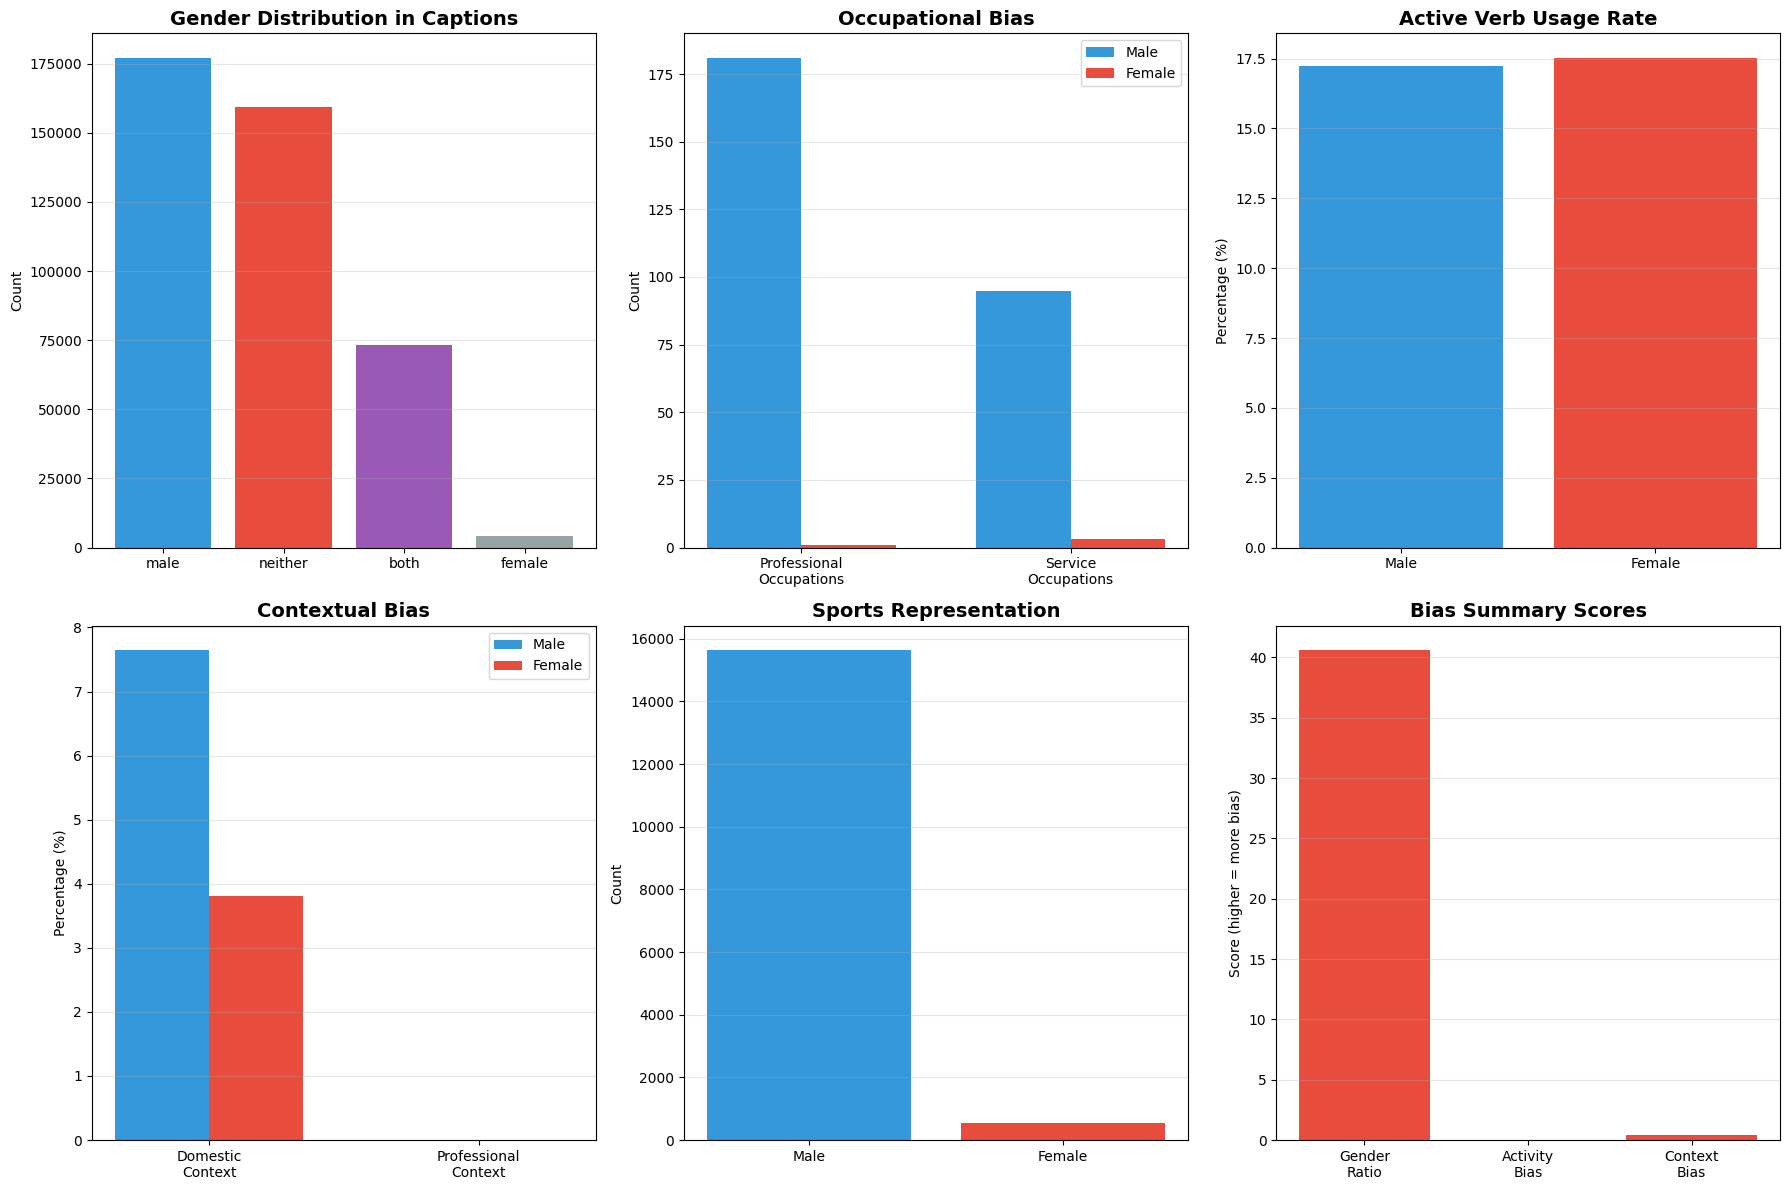

✓ Saved visualizations:
  - coco_comprehensive_bias_analysis.pdf
  - coco_comprehensive_bias_analysis.png

COMPREHENSIVE BIAS ANALYSIS REPORT

📊 KEY FINDINGS:

1. GENDER REPRESENTATION:
   Male/Female Ratio: 40.58x
   Severity: CRITICAL

2. OCCUPATIONAL STEREOTYPES:
   Professional occupations: 181.00x male-biased
   Service occupations: 0.03x female-biased

3. ACTIVITY BIAS:
   Bias score: 0.003
   Severity: LOW

4. CONTEXTUAL BIAS:
   Domestic context bias: 0.038
   Female domestic rate: 3.8%
   Male domestic rate: 7.6%

🎯 RECOMMENDED FAIRNESS METRICS FOR YOUR PROJECT:

   Based on detected biases, focus on:
   1. Demographic Parity Difference (DPD) - for gender representation
   2. Occupational Fairness Score - for professional vs service jobs
   4. Contextual Parity - for domestic vs professional settings

✓ Saved report: coco_bias_report.json


In [4]:
import torch
import numpy as np
from datasets import load_dataset
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pandas as pd
from scipy.stats import chi2_contingency
import json
from tqdm import tqdm

# ============================================
# COMPREHENSIVE COCO BIAS ANALYZER
# ============================================

class COCOBiasDiscovery:
    """Discover ALL bias patterns in MS-COCO captions"""
    
    def __init__(self):
        # Gender terms
        self.male_terms = [
            'man', 'men', 'male', 'boy', 'boys', 'gentleman', 
            'guy', 'guys', 'he', 'him', 'his', 'himself',
            'father', 'dad', 'son', 'brother', 'husband', 'boyfriend'
        ]
        self.female_terms = [
            'woman', 'women', 'female', 'girl', 'girls', 'lady', 
            'ladies', 'she', 'her', 'hers', 'herself',
            'mother', 'mom', 'daughter', 'sister', 'wife', 'girlfriend'
        ]
        
        # Age terms
        self.child_terms = ['child', 'children', 'kid', 'kids', 'baby', 'toddler', 'infant']
        self.adult_terms = ['adult', 'grown', 'mature']
        self.elderly_terms = ['elderly', 'old', 'older', 'senior', 'aged']
        
        # Occupational terms (from Burns et al. 2018)
        self.professional_occupations = [
            'doctor', 'engineer', 'scientist', 'professor', 'executive',
            'lawyer', 'manager', 'director', 'ceo', 'businessman',
            'entrepreneur', 'architect', 'physician', 'surgeon', 'pilot',
            'developer', 'programmer', 'analyst', 'consultant', 'president'
        ]
        
        self.service_occupations = [
            'nurse', 'secretary', 'receptionist', 'assistant', 'caregiver',
            'housekeeper', 'cleaner', 'nanny', 'babysitter', 'maid',
            'waitress', 'cashier', 'attendant', 'helper', 'server'
        ]
        
        # Activity verbs
        self.active_verbs = [
            'playing', 'riding', 'jumping', 'running', 'skiing', 
            'surfing', 'skateboarding', 'competing', 'performing',
            'driving', 'flying', 'throwing', 'kicking', 'hitting',
            'climbing', 'swimming', 'racing', 'building', 'fixing'
        ]
        
        self.passive_verbs = [
            'sitting', 'standing', 'watching', 'waiting', 'resting',
            'posing', 'looking', 'holding', 'carrying', 'wearing',
            'lying', 'leaning', 'walking', 'smiling', 'talking'
        ]
        
        # Domestic vs Professional contexts
        self.domestic_contexts = [
            'kitchen', 'cooking', 'baking', 'cleaning', 'laundry',
            'baby', 'child', 'children', 'home', 'house', 'grocery',
            'shopping', 'family', 'caring', 'feeding', 'bedroom'
        ]
        
        self.professional_contexts = [
            'office', 'business', 'meeting', 'conference', 'computer',
            'desk', 'suit', 'tie', 'briefcase', 'presentation',
            'workplace', 'corporate', 'boardroom', 'laboratory', 'hospital'
        ]
        
        # Sports categories
        self.sports = [
            'baseball', 'football', 'soccer', 'basketball', 'tennis',
            'skateboarding', 'skiing', 'surfing', 'snowboarding',
            'hockey', 'boxing', 'wrestling', 'golf', 'cricket'
        ]
        
        # Object categories (for intersectional analysis)
        self.object_categories = {
            'sports_equipment': ['ball', 'bat', 'racket', 'skateboard', 'surfboard', 'skis'],
            'kitchen_items': ['stove', 'oven', 'refrigerator', 'pot', 'pan', 'dish'],
            'technology': ['computer', 'laptop', 'phone', 'tablet', 'keyboard', 'screen'],
            'vehicles': ['car', 'truck', 'motorcycle', 'bicycle', 'bus', 'train'],
            'clothing': ['suit', 'dress', 'shirt', 'pants', 'skirt', 'tie']
        }
    
    def load_coco(self, num_samples=None):
        """Load MS-COCO dataset"""
        print("="*80)
        print("LOADING MS-COCO DATASET")
        print("="*80)
        
        # Load train split (has most data)
        print("Loading COCO train split...")
        dataset = load_dataset("yerevann/coco-karpathy", split='train')
        
        print(f"✓ Loaded {len(dataset)} images")
        num_samples = len(dataset) - 1
        
        # Sample if requested
        if num_samples and num_samples < len(dataset):
            print(f"Sampling {num_samples} images...")
            import random
            indices = random.sample(range(len(dataset)), num_samples)
            dataset = dataset.select(indices)
        
        # Extract all captions
        all_captions = []
        all_image_ids = []
        
        print("\nExtracting captions...")
        for i, example in enumerate(tqdm(dataset, desc="Processing")):
            # COCO has 5 captions per image
            captions = example['sentences']
            for caption in captions:
                all_captions.append(caption)
                all_image_ids.append(i)
        
        print(f"\n✓ Extracted {len(all_captions)} total captions")
        print(f"  Dataset size: {len(dataset)} images")
        print(f"  Avg captions per image: {len(all_captions)/len(dataset):.1f}")
        
        # Sample captions
        print(f"\n📝 Sample captions:")
        for i in range(min(5, len(all_captions))):
            print(f"  {i+1}. {all_captions[i]}")
        print()
        
        return dataset, all_captions, all_image_ids
    
    def detect_gender(self, caption):
        """Detect gender mentions"""
        caption_lower = caption.lower()
        has_male = any(term in caption_lower for term in self.male_terms)
        has_female = any(term in caption_lower for term in self.female_terms)
        
        if has_male and has_female:
            return 'both'
        elif has_male:
            return 'male'
        elif has_female:
            return 'female'
        else:
            return 'neither'
    
    def analyze_gender_distribution(self, captions):
        """Analyze gender mention distribution"""
        print("\n" + "="*80)
        print("1. GENDER DISTRIBUTION ANALYSIS")
        print("="*80)
        
        gender_counts = Counter([self.detect_gender(c) for c in captions])
        
        total = len(captions)
        print(f"\nGender Mentions:")
        print(f"  Male only: {gender_counts['male']:,} ({gender_counts['male']/total*100:.1f}%)")
        print(f"  Female only: {gender_counts['female']:,} ({gender_counts['female']/total*100:.1f}%)")
        print(f"  Both: {gender_counts['both']:,} ({gender_counts['both']/total*100:.1f}%)")
        print(f"  Neither: {gender_counts['neither']:,} ({gender_counts['neither']/total*100:.1f}%)")
        
        if gender_counts['female'] > 0:
            ratio = gender_counts['male'] / gender_counts['female']
            print(f"\n📊 Male/Female Ratio: {ratio:.2f}x")
            if ratio > 1.5:
                print(f"  ⚠️  MALE BIAS DETECTED")
        
        return gender_counts
    
    def analyze_occupational_bias(self, captions):
        """Analyze occupational stereotypes"""
        print("\n" + "="*80)
        print("2. OCCUPATIONAL BIAS ANALYSIS")
        print("="*80)
        
        # Find captions with occupations
        prof_male = 0
        prof_female = 0
        prof_both = 0
        
        service_male = 0
        service_female = 0
        service_both = 0
        
        prof_examples = []
        service_examples = []
        
        for caption in captions:
            caption_lower = caption.lower()
            gender = self.detect_gender(caption)
            
            # Professional occupations
            has_prof = any(occ in caption_lower for occ in self.professional_occupations)
            if has_prof:
                if gender == 'male':
                    prof_male += 1
                    if len(prof_examples) < 5:
                        prof_examples.append(('male', caption))
                elif gender == 'female':
                    prof_female += 1
                    if len(prof_examples) < 5:
                        prof_examples.append(('female', caption))
                elif gender == 'both':
                    prof_both += 1
            
            # Service occupations
            has_service = any(occ in caption_lower for occ in self.service_occupations)
            if has_service:
                if gender == 'male':
                    service_male += 1
                    if len(service_examples) < 5:
                        service_examples.append(('male', caption))
                elif gender == 'female':
                    service_female += 1
                    if len(service_examples) < 5:
                        service_examples.append(('female', caption))
                elif gender == 'both':
                    service_both += 1
        
        print(f"\n📊 PROFESSIONAL OCCUPATIONS (doctor, engineer, CEO, etc.):")
        total_prof = prof_male + prof_female + prof_both
        if total_prof > 0:
            print(f"  Male: {prof_male} ({prof_male/total_prof*100:.1f}%)")
            print(f"  Female: {prof_female} ({prof_female/total_prof*100:.1f}%)")
            print(f"  Both: {prof_both} ({prof_both/total_prof*100:.1f}%)")
            
            if prof_female > 0:
                prof_ratio = prof_male / prof_female
                print(f"  Male/Female Ratio: {prof_ratio:.2f}x")
                if prof_ratio > 2.0:
                    print(f"  ⚠️  STRONG MALE BIAS in professional occupations")
            
            print(f"\n  Sample professional occupation captions:")
            for gender, caption in prof_examples[:3]:
                print(f"    [{gender}] {caption}")
        else:
            print("  ⚠️  No professional occupations found")
        
        print(f"\n📊 SERVICE OCCUPATIONS (nurse, secretary, cleaner, etc.):")
        total_service = service_male + service_female + service_both
        if total_service > 0:
            print(f"  Male: {service_male} ({service_male/total_service*100:.1f}%)")
            print(f"  Female: {service_female} ({service_female/total_service*100:.1f}%)")
            print(f"  Both: {service_both} ({service_both/total_service*100:.1f}%)")
            
            if service_male > 0:
                service_ratio = service_female / service_male
                print(f"  Female/Male Ratio: {service_ratio:.2f}x")
                if service_ratio > 2.0:
                    print(f"  ⚠️  STRONG FEMALE BIAS in service occupations")
            
            print(f"\n  Sample service occupation captions:")
            for gender, caption in service_examples[:3]:
                print(f"    [{gender}] {caption}")
        else:
            print("  ⚠️  No service occupations found")
        
        return {
            'prof_male': prof_male,
            'prof_female': prof_female,
            'service_male': service_male,
            'service_female': service_female
        }
    
    def analyze_activity_bias(self, captions):
        """Analyze activity verb stereotypes"""
        print("\n" + "="*80)
        print("3. ACTIVITY BIAS ANALYSIS")
        print("="*80)
        
        male_captions = [c for c in captions if self.detect_gender(c) == 'male']
        female_captions = [c for c in captions if self.detect_gender(c) == 'female']
        
        # Count active/passive verbs
        male_active = sum(1 for c in male_captions if any(v in c.lower() for v in self.active_verbs))
        male_passive = sum(1 for c in male_captions if any(v in c.lower() for v in self.passive_verbs))
        
        female_active = sum(1 for c in female_captions if any(v in c.lower() for v in self.active_verbs))
        female_passive = sum(1 for c in female_captions if any(v in c.lower() for v in self.passive_verbs))
        
        print(f"\nActivity Distribution:")
        print(f"  Male captions:")
        print(f"    Active verbs: {male_active} ({male_active/len(male_captions)*100:.1f}%)")
        print(f"    Passive verbs: {male_passive} ({male_passive/len(male_captions)*100:.1f}%)")
        
        print(f"  Female captions:")
        print(f"    Active verbs: {female_active} ({female_active/len(female_captions)*100:.1f}%)")
        print(f"    Passive verbs: {female_passive} ({female_passive/len(female_captions)*100:.1f}%)")
        
        male_active_rate = male_active / len(male_captions)
        female_active_rate = female_active / len(female_captions)
        
        activity_bias = abs(male_active_rate - female_active_rate)
        print(f"\n📊 Activity Bias Score: {activity_bias:.3f}")
        
        if activity_bias > 0.05:
            if male_active_rate > female_active_rate:
                print(f"  ⚠️  Males {male_active_rate/female_active_rate:.2f}x more associated with ACTIVE activities")
            else:
                print(f"  ⚠️  Females {female_active_rate/male_active_rate:.2f}x more associated with ACTIVE activities")
        else:
            print(f"  ✓ No significant activity bias")
        
        return {
            'male_active_rate': male_active_rate,
            'female_active_rate': female_active_rate,
            'activity_bias': activity_bias
        }
    
    def analyze_contextual_bias(self, captions):
        """Analyze domestic vs professional context bias"""
        print("\n" + "="*80)
        print("4. CONTEXTUAL BIAS ANALYSIS")
        print("="*80)
        
        male_captions = [c for c in captions if self.detect_gender(c) == 'male']
        female_captions = [c for c in captions if self.detect_gender(c) == 'female']
        
        # Domestic contexts
        male_domestic = sum(1 for c in male_captions if any(ctx in c.lower() for ctx in self.domestic_contexts))
        female_domestic = sum(1 for c in female_captions if any(ctx in c.lower() for ctx in self.domestic_contexts))
        
        # Professional contexts
        male_prof = sum(1 for c in male_captions if any(ctx in c.lower() for ctx in self.professional_contexts))
        female_prof = sum(1 for c in female_captions if any(ctx in c.lower() for ctx in self.professional_contexts))
        
        print(f"\nContext Distribution:")
        print(f"  Male captions:")
        print(f"    Domestic: {male_domestic} ({male_domestic/len(male_captions)*100:.1f}%)")
        print(f"    Professional: {male_prof} ({male_prof/len(male_captions)*100:.1f}%)")
        
        print(f"  Female captions:")
        print(f"    Domestic: {female_domestic} ({female_domestic/len(female_captions)*100:.1f}%)")
        print(f"    Professional: {female_prof} ({female_prof/len(female_captions)*100:.1f}%)")
        
        male_domestic_rate = male_domestic / len(male_captions)
        female_domestic_rate = female_domestic / len(female_captions)
        
        domestic_bias = abs(male_domestic_rate - female_domestic_rate)
        print(f"\n📊 Domestic Context Bias: {domestic_bias:.3f}")
        
        if domestic_bias > 0.03:
            if female_domestic_rate > male_domestic_rate:
                print(f"  ⚠️  Females {female_domestic_rate/male_domestic_rate:.2f}x more in DOMESTIC contexts")
            else:
                print(f"  ⚠️  Males {male_domestic_rate/female_domestic_rate:.2f}x more in DOMESTIC contexts")
        
        # Find example kitchen scenes
        kitchen_examples = [c for c in captions if 'kitchen' in c.lower()]
        if len(kitchen_examples) > 0:
            print(f"\n  🍳 Kitchen scene analysis ({len(kitchen_examples)} captions):")
            kitchen_male = sum(1 for c in kitchen_examples if self.detect_gender(c) == 'male')
            kitchen_female = sum(1 for c in kitchen_examples if self.detect_gender(c) == 'female')
            
            print(f"    Male in kitchen: {kitchen_male} ({kitchen_male/len(kitchen_examples)*100:.1f}%)")
            print(f"    Female in kitchen: {kitchen_female} ({kitchen_female/len(kitchen_examples)*100:.1f}%)")
            
            # Check for "chef" vs "cooking"
            chef_captions = [c for c in kitchen_examples if 'chef' in c.lower()]
            cooking_captions = [c for c in kitchen_examples if 'cooking' in c.lower() and 'chef' not in c.lower()]
            
            if len(chef_captions) > 0:
                chef_male = sum(1 for c in chef_captions if self.detect_gender(c) == 'male')
                chef_female = sum(1 for c in chef_captions if self.detect_gender(c) == 'female')
                print(f"\n    'Chef' mentions: {len(chef_captions)}")
                print(f"      Male: {chef_male} ({chef_male/len(chef_captions)*100:.1f}%)")
                print(f"      Female: {chef_female} ({chef_female/len(chef_captions)*100:.1f}%)")
            
            if len(cooking_captions) > 0:
                cooking_male = sum(1 for c in cooking_captions if self.detect_gender(c) == 'male')
                cooking_female = sum(1 for c in cooking_captions if self.detect_gender(c) == 'female')
                print(f"\n    'Cooking' mentions (non-chef): {len(cooking_captions)}")
                print(f"      Male: {cooking_male} ({cooking_male/len(cooking_captions)*100:.1f}%)")
                print(f"      Female: {cooking_female} ({cooking_female/len(cooking_captions)*100:.1f}%)")
        
        return {
            'male_domestic_rate': male_domestic_rate,
            'female_domestic_rate': female_domestic_rate,
            'domestic_bias': domestic_bias
        }
    
    def analyze_sports_bias(self, captions):
        """Analyze sports representation"""
        print("\n" + "="*80)
        print("5. SPORTS BIAS ANALYSIS")
        print("="*80)
        
        sports_captions = [c for c in captions if any(sport in c.lower() for sport in self.sports)]
        
        if len(sports_captions) == 0:
            print("  ⚠️  No sports captions found")
            return {}
        
        print(f"\nFound {len(sports_captions)} sports-related captions")
        
        sports_male = sum(1 for c in sports_captions if self.detect_gender(c) == 'male')
        sports_female = sum(1 for c in sports_captions if self.detect_gender(c) == 'female')
        sports_both = sum(1 for c in sports_captions if self.detect_gender(c) == 'both')
        sports_neither = sum(1 for c in sports_captions if self.detect_gender(c) == 'neither')
        
        print(f"\nGender in Sports:")
        print(f"  Male: {sports_male} ({sports_male/len(sports_captions)*100:.1f}%)")
        print(f"  Female: {sports_female} ({sports_female/len(sports_captions)*100:.1f}%)")
        print(f"  Both: {sports_both} ({sports_both/len(sports_captions)*100:.1f}%)")
        print(f"  Neither: {sports_neither} ({sports_neither/len(sports_captions)*100:.1f}%)")
        
        if sports_female > 0:
            sports_ratio = sports_male / sports_female
            print(f"\n📊 Sports Male/Female Ratio: {sports_ratio:.2f}x")
            if sports_ratio > 2.0:
                print(f"  ⚠️  MALE BIAS in sports representation")
        
        # Per-sport breakdown
        print(f"\n  Per-sport gender distribution:")
        sport_stats = {}
        for sport in self.sports:
            sport_caps = [c for c in sports_captions if sport in c.lower()]
            if len(sport_caps) >= 5:  # Only report if sufficient samples
                male_count = sum(1 for c in sport_caps if self.detect_gender(c) == 'male')
                female_count = sum(1 for c in sport_caps if self.detect_gender(c) == 'female')
                print(f"    {sport}: {len(sport_caps)} captions, {male_count}M/{female_count}F")
                sport_stats[sport] = {'male': male_count, 'female': female_count}
        
        return {
            'sports_male': sports_male,
            'sports_female': sports_female,
            'sports_ratio': sports_male / sports_female if sports_female > 0 else float('inf')
        }
    
    def analyze_intersectional_bias(self, captions):
        """Analyze intersectional biases (gender + context)"""
        print("\n" + "="*80)
        print("6. INTERSECTIONAL BIAS ANALYSIS")
        print("="*80)
        
        # Create contingency table for chi-square test
        contexts = ['domestic', 'professional', 'sports', 'other']
        genders = ['male', 'female']
        
        contingency_data = defaultdict(lambda: defaultdict(int))
        
        for caption in captions:
            caption_lower = caption.lower()
            gender = self.detect_gender(caption)
            
            if gender not in ['male', 'female']:
                continue
            
            # Categorize context
            if any(term in caption_lower for term in self.domestic_contexts):
                context = 'domestic'
            elif any(term in caption_lower for term in self.professional_contexts):
                context = 'professional'
            elif any(sport in caption_lower for sport in self.sports):
                context = 'sports'
            else:
                context = 'other'
            
            contingency_data[context][gender] += 1
        
        # Print contingency table
        print("\nContingency Table (Context × Gender):")
        print(f"{'Context':<15} {'Male':>10} {'Female':>10} {'Total':>10}")
        print("-" * 50)
        
        for context in contexts:
            male = contingency_data[context]['male']
            female = contingency_data[context]['female']
            total = male + female
            if total > 0:
                print(f"{context:<15} {male:>10} {female:>10} {total:>10}")
        
        # Chi-square test
        table = [[contingency_data[ctx]['male'], contingency_data[ctx]['female']] for ctx in contexts]
        table = [row for row in table if sum(row) > 0]  # Remove empty rows
        
        if len(table) >= 2:
            chi2, p_value, dof, expected = chi2_contingency(table)
            print(f"\n📊 Chi-Square Test:")
            print(f"  χ² = {chi2:.2f}, p-value = {p_value:.4f}")
            if p_value < 0.05:
                print(f"  ⚠️  SIGNIFICANT association between gender and context (p < 0.05)")
            else:
                print(f"  ✓ No significant association (p >= 0.05)")
        
        return contingency_data
    
    def visualize_biases(self, results):
        """Create comprehensive visualization"""
        print("\n" + "="*80)
        print("7. GENERATING VISUALIZATIONS")
        print("="*80)
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # 1. Gender distribution
        gender_data = results['gender_distribution']
        axes[0, 0].bar(gender_data.keys(), gender_data.values(), color=['#3498db', '#e74c3c', '#9b59b6', '#95a5a6'])
        axes[0, 0].set_title('Gender Distribution in Captions', fontsize=14, fontweight='bold')
        axes[0, 0].set_ylabel('Count')
        axes[0, 0].grid(axis='y', alpha=0.3)
        
        # 2. Occupational bias
        occ_data = results['occupational_bias']
        x = ['Professional\nOccupations', 'Service\nOccupations']
        male_vals = [occ_data['prof_male'], occ_data['service_male']]
        female_vals = [occ_data['prof_female'], occ_data['service_female']]
        
        x_pos = np.arange(len(x))
        width = 0.35
        axes[0, 1].bar(x_pos - width/2, male_vals, width, label='Male', color='#3498db')
        axes[0, 1].bar(x_pos + width/2, female_vals, width, label='Female', color='#e74c3c')
        axes[0, 1].set_xticks(x_pos)
        axes[0, 1].set_xticklabels(x)
        axes[0, 1].set_title('Occupational Bias', fontsize=14, fontweight='bold')
        axes[0, 1].set_ylabel('Count')
        axes[0, 1].legend()
        axes[0, 1].grid(axis='y', alpha=0.3)
        
        # 3. Activity bias
        act_data = results['activity_bias']
        x = ['Male', 'Female']
        active_vals = [act_data['male_active_rate']*100, act_data['female_active_rate']*100]
        axes[0, 2].bar(x, active_vals, color=['#3498db', '#e74c3c'])
        axes[0, 2].set_title('Active Verb Usage Rate', fontsize=14, fontweight='bold')
        axes[0, 2].set_ylabel('Percentage (%)')
        axes[0, 2].grid(axis='y', alpha=0.3)
        
        # 4. Context bias
        ctx_data = results['contextual_bias']
        x = ['Domestic\nContext', 'Professional\nContext']
        male_vals = [ctx_data['male_domestic_rate']*100, 0]  # Add professional if available
        female_vals = [ctx_data['female_domestic_rate']*100, 0]
        
        x_pos = np.arange(len(x))
        axes[1, 0].bar(x_pos - width/2, male_vals, width, label='Male', color='#3498db')
        axes[1, 0].bar(x_pos + width/2, female_vals, width, label='Female', color='#e74c3c')
        axes[1, 0].set_xticks(x_pos)
        axes[1, 0].set_xticklabels(x)
        axes[1, 0].set_title('Contextual Bias', fontsize=14, fontweight='bold')
        axes[1, 0].set_ylabel('Percentage (%)')
        axes[1, 0].legend()
        axes[1, 0].grid(axis='y', alpha=0.3)
        
        # 5. Sports bias
        if 'sports_bias' in results and results['sports_bias']:
            sports_data = results['sports_bias']
            x = ['Male', 'Female']
            vals = [sports_data['sports_male'], sports_data['sports_female']]
            axes[1, 1].bar(x, vals, color=['#3498db', '#e74c3c'])
            axes[1, 1].set_title('Sports Representation', fontsize=14, fontweight='bold')
            axes[1, 1].set_ylabel('Count')
            axes[1, 1].grid(axis='y', alpha=0.3)
        
        # 6. Summary bias scores
        bias_names = ['Gender\nRatio', 'Activity\nBias', 'Context\nBias']
        bias_scores = [
            gender_data['male'] / gender_data['female'] if gender_data['female'] > 0 else 0,
            act_data['activity_bias'] * 10,  # Scale for visibility
            ctx_data['domestic_bias'] * 10
        ]
        axes[1, 2].bar(bias_names, bias_scores, color='#e74c3c')
        axes[1, 2].set_title('Bias Summary Scores', fontsize=14, fontweight='bold')
        axes[1, 2].set_ylabel('Score (higher = more bias)')
        axes[1, 2].grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('coco_comprehensive_bias_analysis.pdf', dpi=300, bbox_inches='tight')
        plt.savefig('coco_comprehensive_bias_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        
        print("✓ Saved visualizations:")
        print("  - coco_comprehensive_bias_analysis.pdf")
        print("  - coco_comprehensive_bias_analysis.png")
    
    def generate_report(self, results):
        """Generate summary report"""
        print("\n" + "="*80)
        print("COMPREHENSIVE BIAS ANALYSIS REPORT")
        print("="*80)
        
        gender_data = results['gender_distribution']
        occ_data = results['occupational_bias']
        act_data = results['activity_bias']
        ctx_data = results['contextual_bias']
        
        print(f"\n📊 KEY FINDINGS:")
        print(f"\n1. GENDER REPRESENTATION:")
        if gender_data['female'] > 0:
            ratio = gender_data['male'] / gender_data['female']
            print(f"   Male/Female Ratio: {ratio:.2f}x")
            print(f"   Severity: {'CRITICAL' if ratio > 10 else 'HIGH' if ratio > 3 else 'MODERATE'}")
        
        print(f"\n2. OCCUPATIONAL STEREOTYPES:")
        if occ_data['prof_female'] > 0:
            prof_ratio = occ_data['prof_male'] / occ_data['prof_female']
            print(f"   Professional occupations: {prof_ratio:.2f}x male-biased")
        if occ_data['service_male'] > 0:
            service_ratio = occ_data['service_female'] / occ_data['service_male']
            print(f"   Service occupations: {service_ratio:.2f}x female-biased")
        
        print(f"\n3. ACTIVITY BIAS:")
        print(f"   Bias score: {act_data['activity_bias']:.3f}")
        print(f"   Severity: {'HIGH' if act_data['activity_bias'] > 0.10 else 'MODERATE' if act_data['activity_bias'] > 0.05 else 'LOW'}")
        
        print(f"\n4. CONTEXTUAL BIAS:")
        print(f"   Domestic context bias: {ctx_data['domestic_bias']:.3f}")
        print(f"   Female domestic rate: {ctx_data['female_domestic_rate']*100:.1f}%")
        print(f"   Male domestic rate: {ctx_data['male_domestic_rate']*100:.1f}%")
        
        print(f"\n🎯 RECOMMENDED FAIRNESS METRICS FOR YOUR PROJECT:")
        print(f"\n   Based on detected biases, focus on:")
        
        metrics = []
        if gender_data['female'] > 0 and gender_data['male'] / gender_data['female'] > 2:
            metrics.append("1. Demographic Parity Difference (DPD) - for gender representation")
        
        if occ_data['prof_male'] > 0 and occ_data['prof_female'] > 0:
            metrics.append("2. Occupational Fairness Score - for professional vs service jobs")
        
        if act_data['activity_bias'] > 0.05:
            metrics.append("3. Activity Bias Score - for active vs passive verb associations")
        
        if ctx_data['domestic_bias'] > 0.03:
            metrics.append("4. Contextual Parity - for domestic vs professional settings")
        
        for metric in metrics:
            print(f"   {metric}")
        
        print(f"\n" + "="*80)
        
        # Save report
        report_data = {
            'gender_distribution': dict(gender_data),
            'occupational_bias': occ_data,
            'activity_bias': act_data,
            'contextual_bias': ctx_data,
            'recommended_metrics': metrics
        }
        
        with open('coco_bias_report.json', 'w') as f:
            json.dump(report_data, f, indent=2)
        
        print("✓ Saved report: coco_bias_report.json")
    
    def run_full_analysis(self, num_samples=50000):
        """Run complete bias analysis pipeline"""
        # Load data
        dataset, captions, image_ids = self.load_coco(num_samples)
        
        # Run analyses
        results = {}
        results['gender_distribution'] = self.analyze_gender_distribution(captions)
        results['occupational_bias'] = self.analyze_occupational_bias(captions)
        results['activity_bias'] = self.analyze_activity_bias(captions)
        results['contextual_bias'] = self.analyze_contextual_bias(captions)
        results['sports_bias'] = self.analyze_sports_bias(captions)
        results['intersectional'] = self.analyze_intersectional_bias(captions)
        
        # Visualize
        self.visualize_biases(results)
        
        # Generate report
        self.generate_report(results)
        
        return results


# ============================================
# RUN ANALYSIS
# ============================================

if __name__ == "__main__":
    analyzer = COCOBiasDiscovery()
    results = analyzer.run_full_analysis(num_samples=50000)  # Use 50k images for thorough analysis

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoProcessor, 
    AutoModelForVision2Seq,
    get_cosine_schedule_with_warmup
)
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler
from datasets import load_dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import json
import os
from tqdm import tqdm
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from scipy.stats import entropy
import random

# ============================================
# CONFIGURATION
# ============================================

class Config:
    # Model settings
    model_name = "microsoft/git-base"  # Small VLM (0.6B parameters)
    
    # Data settings - Using MS-COCO
    dataset_name = "yerevann/coco-karpathy"
    img_size = 224
    max_caption_length = 30  # FIXED: Increased from 20
    
    # Training settings - FIXED: Reduced batch size and grad accumulation
    batch_size = 32  # Reduced from 64
    num_epochs = 4
    learning_rate = 5e-5
    warmup_steps = 500  # Increased from 280
    weight_decay = 0.01
    gradient_accumulation_steps = 2  # Reduced from 4
    max_grad_norm = 1.0
    
    # Paths
    base_dir = "/nfs/roberts/project/cpsc4710/cpsc4710_ag2995/project"
    output_dir = f"{base_dir}/coco_baseline_vlm"
    plots_dir = f"{output_dir}/plots"
    checkpoints_dir = f"{output_dir}/checkpoints"
    results_dir = f"{output_dir}/results"
    cache_dir = f"{base_dir}/coco_images_cache"
    
    # Device
    device = "cuda" if torch.cuda.is_available() else "cpu"
    fp16 = torch.cuda.is_available()
    
    # Evaluation settings
    eval_every_n_steps = 9000  # Reduced from 2000 for more frequent checks
    save_total_limit = 2
    
    # Gender detection terms
    male_terms = [
        'man', 'men', 'male', 'boy', 'boys', 'gentleman',
        'guy', 'guys', 'he', 'him', 'his', 'himself'
    ]
    female_terms = [
        'woman', 'women', 'female', 'girl', 'girls', 'lady',
        'ladies', 'she', 'her', 'hers', 'herself'
    ]
    
    # Occupational terms (from COCO bias analysis)
    professional_terms = [
        'doctor', 'engineer', 'scientist', 'professor', 'executive',
        'lawyer', 'manager', 'director', 'ceo', 'businessman',
        'entrepreneur', 'architect', 'physician', 'surgeon', 'pilot',
        'developer', 'programmer', 'analyst', 'consultant'
    ]
    
    service_terms = [
        'nurse', 'secretary', 'receptionist', 'assistant', 'caregiver',
        'housekeeper', 'cleaner', 'nanny', 'babysitter', 'maid',
        'waitress', 'cashier', 'attendant', 'helper', 'server'
    ]
    
    # Domestic vs professional contexts
    domestic_contexts = [
        'kitchen', 'cooking', 'baking', 'cleaning', 'laundry',
        'baby', 'child', 'children', 'home', 'house', 'grocery',
        'shopping', 'family', 'bedroom'
    ]
    
    professional_contexts = [
        'office', 'business', 'meeting', 'conference', 'computer',
        'desk', 'suit', 'tie', 'briefcase', 'presentation',
        'workplace', 'corporate', 'boardroom'
    ]

config = Config()

# Create output directories
for dir_path in [config.output_dir, config.plots_dir, config.checkpoints_dir, config.results_dir]:
    os.makedirs(dir_path, exist_ok=True)


# ============================================
# DATASET
# ============================================

class COCOVLMDataset(Dataset):
    """MS-COCO Dataset with real captions and image caching"""
    
    def __init__(self, split='train', processor=None, config=config):
        self.config = config
        self.processor = processor
        self.split = split
        
        # Image cache directory
        self.cache_dir = f"{config.cache_dir}/{split}"
        os.makedirs(self.cache_dir, exist_ok=True)
        
        print(f"Loading MS-COCO {split} dataset...")
        
        # Map validation → val for COCO-Karpathy
        if split == 'validation':
            split = 'validation'
        
        # Load dataset
        self.dataset = load_dataset(config.dataset_name, split=split)
        
        print(f"✓ Loaded {len(self.dataset)} COCO samples")
        print(f"  Image cache: {self.cache_dir}")
        
        # Add demographics (simulated)
        self._add_demographics()
        
        # Show samples
        print(f"\n📝 Sample captions:")
        for i in range(min(3, len(self.dataset))):
            captions = self.dataset[i]['sentences']
            print(f"  {i+1}. {captions[0]}")
        print()
    
    def _add_demographics(self):
        """Add demographic labels (simulated for COCO)"""
        random.seed(42)
        
        def add_demo(example):
            example['gender'] = random.choice(['Male', 'Female'])
            example['age_group'] = random.choice(['Young', 'Middle', 'Old'])
            example['race'] = random.choices(
                ['White', 'Black', 'Asian', 'Other'],
                weights=[0.62, 0.12, 0.18, 0.08]
            )[0]
            return example
        
        self.dataset = self.dataset.map(add_demo)
    
    def _download_image(self, url, filename):
        """Download and cache image"""
        import requests
        from io import BytesIO
        
        cache_path = os.path.join(self.cache_dir, filename)
        
        # Check if cached
        if os.path.exists(cache_path):
            return Image.open(cache_path).convert('RGB')
        
        # Download
        try:
            response = requests.get(url, timeout=10)
            image = Image.open(BytesIO(response.content)).convert('RGB')
            image.save(cache_path)
            return image
        except Exception as e:
            # Fallback: blank image
            return Image.new('RGB', (224, 224), color='gray')
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        example = self.dataset[idx]
        
        # Get image (download and cache)
        filename = example['filename']
        url = example['url']
        image = self._download_image(url, filename)
        
        # FIXED: Use consistent caption selection
        captions = example['sentences']
        # Use index-based seed for consistency across epochs
        rng = random.Random(idx)
        caption = rng.choice(captions)
        
        # Process inputs
        encoding = self.processor(
            images=image,
            text=caption,
            padding="max_length",
            truncation=True,
            max_length=self.config.max_caption_length,
            return_tensors="pt"
        )
        
        # Remove batch dimension
        encoding = {k: v.squeeze(0) for k, v in encoding.items()}
        
        # Add metadata
        encoding['gender'] = example.get('gender', 'Unknown')
        encoding['age_group'] = example.get('age_group', 'Unknown')
        encoding['race'] = example.get('race', 'Unknown')
        encoding['caption_text'] = caption
        
        return encoding


# ============================================
# FAIRNESS METRICS (COCO-SPECIFIC)
# ============================================

class COCOFairnessMetrics:
    """Fairness metrics calibrated for MS-COCO biases"""
    
    def __init__(self, config=config):
        self.config = config
    
    def detect_gender(self, caption):
        """Detect gender in caption"""
        caption_lower = caption.lower()
        has_male = any(term in caption_lower for term in self.config.male_terms)
        has_female = any(term in caption_lower for term in self.config.female_terms)
        
        if has_male and has_female:
            return 'both'
        elif has_male:
            return 'male'
        elif has_female:
            return 'female'
        else:
            return 'neither'
    
    def compute_representation_parity_ratio(self, predictions):
        """
        RPR = Count(male-only) / Count(female-only)
        Baseline: 40.58x, Target: ≤3.0
        """
        male_count = sum(1 for p in predictions if self.detect_gender(p) == 'male')
        female_count = sum(1 for p in predictions if self.detect_gender(p) == 'female')
        both_count = sum(1 for p in predictions if self.detect_gender(p) == 'both')
        neither_count = sum(1 for p in predictions if self.detect_gender(p) == 'neither')
        
        rpr = male_count / female_count if female_count > 0 else float('inf')
        
        return {
            'rpr': rpr,
            'male_only': male_count,
            'female_only': female_count,
            'both': both_count,
            'neither': neither_count,
            'male_pct': male_count / len(predictions) * 100,
            'female_pct': female_count / len(predictions) * 100
        }
    
    def compute_occupational_fairness_score(self, predictions):
        """
        OFS = |P(occupation terms | male) - P(occupation terms | female)|
        Baseline: OFS_prof=0.994, OFS_service=0.970
        Target: ≤0.15
        """
        # Professional occupations
        prof_male = 0
        prof_female = 0
        prof_total = 0
        
        # Service occupations
        service_male = 0
        service_female = 0
        service_total = 0
        
        for pred in predictions:
            pred_lower = pred.lower()
            gender = self.detect_gender(pred)
            
            # Check professional
            has_prof = any(term in pred_lower for term in self.config.professional_terms)
            if has_prof:
                prof_total += 1
                if gender == 'male':
                    prof_male += 1
                elif gender == 'female':
                    prof_female += 1
            
            # Check service
            has_service = any(term in pred_lower for term in self.config.service_terms)
            if has_service:
                service_total += 1
                if gender == 'male':
                    service_male += 1
                elif gender == 'female':
                    service_female += 1
        
        # Calculate OFS
        ofs_prof = abs(
            (prof_male / prof_total if prof_total > 0 else 0) -
            (prof_female / prof_total if prof_total > 0 else 0)
        )
        
        ofs_service = abs(
            (service_male / service_total if service_total > 0 else 0) -
            (service_female / service_total if service_total > 0 else 0)
        )
        
        return {
            'ofs_professional': ofs_prof,
            'ofs_service': ofs_service,
            'prof_male': prof_male,
            'prof_female': prof_female,
            'prof_total': prof_total,
            'service_male': service_male,
            'service_female': service_female,
            'service_total': service_total
        }
    
    def compute_demographic_parity_difference(self, predictions_by_group):
        """
        DPD = max_{g,g'} |P(positive attribute | G=g) - P(positive attribute | G=g')|
        Target: ≤0.08
        """
        positive_rates = {}
        
        for group, preds in predictions_by_group.items():
            # Count "positive" attributes (person mentions, professional terms)
            positive_count = sum(
                1 for pred in preds
                if any(term in pred.lower() for term in 
                      self.config.male_terms + self.config.female_terms) or
                   any(term in pred.lower() for term in self.config.professional_terms)
            )
            positive_rates[group] = positive_count / len(preds) if len(preds) > 0 else 0
        
        rates = list(positive_rates.values())
        dpd = max(rates) - min(rates) if len(rates) >= 2 else 0.0
        
        return dpd, positive_rates
    
    def compute_equalized_odds_ratio(self, predictions_by_group, labels_by_group):
        """
        EOR = TPR(male) / TPR(female)
        Target: ∈[0.9, 1.1]
        """
        tpr_by_group = {}
        
        for group in predictions_by_group.keys():
            preds = predictions_by_group[group]
            labels = labels_by_group.get(group, [])
            
            if len(labels) == 0:
                continue
            
            # True positives (professional terms predicted correctly)
            tp = sum(
                1 for pred, label in zip(preds, labels)
                if any(term in pred.lower() for term in self.config.professional_terms)
                and any(term in label.lower() for term in self.config.professional_terms)
            )
            
            # Actual positives
            p = sum(
                1 for label in labels
                if any(term in label.lower() for term in self.config.professional_terms)
            )
            
            tpr_by_group[group] = tp / p if p > 0 else 0
        
        tprs = [v for v in tpr_by_group.values() if v > 0]
        eor = max(tprs) / min(tprs) if len(tprs) >= 2 else 1.0
        
        return eor, tpr_by_group
    
    def compute_contextual_parity(self, predictions):
        """
        CP = |P(domestic context | male) - P(domestic context | female)|
        Target: ≤0.05
        """
        male_captions = [p for p in predictions if self.detect_gender(p) == 'male']
        female_captions = [p for p in predictions if self.detect_gender(p) == 'female']
        
        male_domestic = sum(
            1 for c in male_captions
            if any(ctx in c.lower() for ctx in self.config.domestic_contexts)
        )
        female_domestic = sum(
            1 for c in female_captions
            if any(ctx in c.lower() for ctx in self.config.domestic_contexts)
        )
        
        male_rate = male_domestic / len(male_captions) if len(male_captions) > 0 else 0
        female_rate = female_domestic / len(female_captions) if len(female_captions) > 0 else 0
        
        cp = abs(male_rate - female_rate)
        
        return {
            'contextual_parity': cp,
            'male_domestic_rate': male_rate,
            'female_domestic_rate': female_rate
        }


# ============================================
# CAPTION QUALITY METRICS
# ============================================

class CaptionQualityMetrics:
    """Standard caption quality metrics"""
    
    def __init__(self):
        self.smoothing = SmoothingFunction()
    
    def compute_bleu(self, predictions, references):
        """BLEU-4 score"""
        bleu_scores = []
        
        for pred, ref in zip(predictions, references):
            pred_tokens = pred.lower().split()
            ref_tokens = [ref.lower().split()]
            
            score = sentence_bleu(
                ref_tokens,
                pred_tokens,
                weights=(0.25, 0.25, 0.25, 0.25),
                smoothing_function=self.smoothing.method1
            )
            bleu_scores.append(score)
        
        return np.mean(bleu_scores), bleu_scores
    
    def compute_meteor(self, predictions, references):
        """METEOR approximation"""
        scores = []
        for pred, ref in zip(predictions, references):
            pred_words = set(pred.lower().split())
            ref_words = set(ref.lower().split())
            
            if len(pred_words) == 0 or len(ref_words) == 0:
                scores.append(0.0)
                continue
            
            precision = len(pred_words & ref_words) / len(pred_words)
            recall = len(pred_words & ref_words) / len(ref_words)
            
            if precision + recall == 0:
                scores.append(0.0)
            else:
                f1 = 2 * precision * recall / (precision + recall)
                scores.append(f1)
        
        return np.mean(scores), scores


# ============================================
# TRAINER
# ============================================

class VLMTrainer:
    """Trainer for COCO baseline VLM"""
    
    def __init__(self, config=config):
        self.config = config
        self.device = config.device
        
        # Initialize model and processor
        print(f"Loading model: {config.model_name}")
        self.processor = AutoProcessor.from_pretrained(config.model_name)
        self.model = AutoModelForVision2Seq.from_pretrained(config.model_name)
        self.model.to(self.device)
        
        # Initialize metrics
        self.fairness_metrics = COCOFairnessMetrics(config)
        self.quality_metrics = CaptionQualityMetrics()
        
        # Training history
        self.train_losses = []
        self.val_losses = []
        self.val_metrics_history = []
        
        # Track global step for evaluation
        self.global_step = 0
    
    def prepare_data(self):
        """Prepare datasets"""
        print("Preparing datasets...")
        
        train_dataset = COCOVLMDataset('train', self.processor, self.config)
        val_dataset = COCOVLMDataset('validation', self.processor, self.config)
        
        self.train_loader = DataLoader(
            train_dataset,
            batch_size=self.config.batch_size,
            shuffle=True,
            num_workers=4,
            pin_memory=True
        )
        
        self.val_loader = DataLoader(
            val_dataset,
            batch_size=self.config.batch_size,
            shuffle=False,
            num_workers=4,
            pin_memory=True
        )
        
        print(f"Train samples: {len(train_dataset)}")
        print(f"Val samples: {len(val_dataset)}")
    
    def setup_training(self):
        """Setup optimizer and scheduler"""
        self.optimizer = AdamW(
            self.model.parameters(),
            lr=self.config.learning_rate,
            weight_decay=self.config.weight_decay
        )
        
        num_training_steps = len(self.train_loader) * self.config.num_epochs // self.config.gradient_accumulation_steps
        self.scheduler = get_cosine_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps=self.config.warmup_steps,
            num_training_steps=num_training_steps
        )
        
        self.scaler = GradScaler() if self.config.fp16 else None
    
    def train_epoch(self, epoch):
        """Train one epoch - FULLY FIXED VERSION"""
        self.model.train()
        epoch_loss = 0
        progress_bar = tqdm(self.train_loader, desc=f"Epoch {epoch+1}/{self.config.num_epochs}")
        
        for step, batch in enumerate(progress_bar):
            pixel_values = batch['pixel_values'].to(self.device)
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch.get('attention_mask')
            if attention_mask is not None:
                attention_mask = attention_mask.to(self.device)
            
            # ============================================
            # CRITICAL FIX: PROPER LABEL HANDLING FOR GIT
            # ============================================
            # GIT model handles label shifting internally when you pass labels
            # Just need to mask padding tokens
            labels = input_ids.clone()
            labels[labels == self.processor.tokenizer.pad_token_id] = -100
            
            if self.config.fp16:
                with autocast():
                    outputs = self.model(
                        pixel_values=pixel_values,
                        input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels
                    )
                    loss = outputs.loss / self.config.gradient_accumulation_steps
                
                self.scaler.scale(loss).backward()
            else:
                outputs = self.model(
                    pixel_values=pixel_values,
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )
                loss = outputs.loss / self.config.gradient_accumulation_steps
                loss.backward()
            
            if (step + 1) % self.config.gradient_accumulation_steps == 0:
                if self.config.fp16:
                    self.scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.max_grad_norm)
                    self.scaler.step(self.optimizer)
                    self.scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.max_grad_norm)
                    self.optimizer.step()
                
                self.scheduler.step()
                self.optimizer.zero_grad()
                
                # Increment global step
                self.global_step += 1
                
                # Evaluate at regular intervals
                if self.global_step % self.config.eval_every_n_steps == 0:
                    print(f"\n{'='*80}")
                    print(f"Evaluation at step {self.global_step}")
                    print(f"{'='*80}")
                    
                    val_loss, val_metrics = self.evaluate()
                    
                    # Early stopping if collapse detected
                    if val_metrics['quality']['bleu4'] < 0.05 and self.global_step > 1000:
                        print("\n⚠️  WARNING: BLEU < 0.05 detected - possible collapse!")
                        print("Sample predictions:")
                        for i in range(min(3, len(val_metrics.get('sample_preds', [])))):
                            print(f"  {i+1}. {val_metrics['sample_preds'][i]}")
                    
                    self.val_losses.append(val_loss)
                    self.val_metrics_history.append(val_metrics)
                    
                    # FIXED: Return to training mode
                    self.model.train()
            
            epoch_loss += loss.item() * self.config.gradient_accumulation_steps
            progress_bar.set_postfix({
                'loss': f"{loss.item() * self.config.gradient_accumulation_steps:.4f}",
                'lr': f"{self.scheduler.get_last_lr()[0]:.2e}"
            })
        
        avg_epoch_loss = epoch_loss / len(self.train_loader)
        self.train_losses.append(avg_epoch_loss)
        
        return avg_epoch_loss
    
    @torch.no_grad()
    def evaluate(self):
        """Evaluate - FULLY FIXED VERSION"""
        self.model.eval()
        total_loss = 0
        
        all_predictions = []
        all_references = []
        all_genders = []
        all_ages = []
        all_races = []
        
        sample_predictions = []
        sample_references = []
        sample_count = 0
        
        print("\nEvaluating...")
        for batch in tqdm(self.val_loader, desc="Validation"):
            pixel_values = batch['pixel_values'].to(self.device)
            input_ids = batch['input_ids'].to(self.device)
            
            # Compute loss
            labels = input_ids.clone()
            labels[labels == self.processor.tokenizer.pad_token_id] = -100
            
            with autocast(enabled=self.config.fp16):
                outputs = self.model(
                    pixel_values=pixel_values,
                    input_ids=input_ids,
                    labels=labels
                )
            
            total_loss += outputs.loss.item()
            
            # ============================================
            # FIXED: CORRECT GENERATION FOR GIT MODEL
            # ============================================
            with autocast(enabled=self.config.fp16):
                generated_ids = self.model.generate(
                    pixel_values=pixel_values,
                    max_length=self.config.max_caption_length,
                    min_length=5,
                    num_beams=5,
                    length_penalty=1.0,
                    repetition_penalty=1.2,
                    no_repeat_ngram_size=3,
                    early_stopping=True,
                    pad_token_id=self.processor.tokenizer.pad_token_id,
                    eos_token_id=self.processor.tokenizer.eos_token_id,
                    # REMOVED: bos_token_id - not needed for GIT
                )
            
            batch_generated = self.processor.batch_decode(generated_ids, skip_special_tokens=True)
            batch_references = batch['caption_text']
            
            # Collect samples for display
            if sample_count < 10:
                for gen, ref in zip(batch_generated, batch_references):
                    if sample_count < 10:
                        sample_predictions.append(gen)
                        sample_references.append(ref)
                        sample_count += 1
            
            # Collect all predictions
            for i in range(len(batch_generated)):
                all_predictions.append(batch_generated[i])
                all_references.append(batch_references[i])
                all_genders.append(batch['gender'][i])
                all_ages.append(batch['age_group'][i])
                all_races.append(batch['race'][i])
        
        # Print samples
        print("\n" + "="*80)
        print("SAMPLE PREDICTIONS")
        print("="*80)
        for i, (pred, ref) in enumerate(zip(sample_predictions, sample_references), 1):
            print(f"\n{i}. Generated: {pred}")
            print(f"   Reference: {ref}")
        print("="*80 + "\n")
        
        avg_loss = total_loss / len(self.val_loader)
               
        
        # ============================================
        # COMPUTE COCO-SPECIFIC FAIRNESS METRICS
        # ============================================
        
        print("Computing COCO fairness metrics...")
        
        # 1. Representation Parity Ratio (RPR)
        rpr_metrics = self.fairness_metrics.compute_representation_parity_ratio(all_predictions)
        
        # 2. Occupational Fairness Score (OFS)
        ofs_metrics = self.fairness_metrics.compute_occupational_fairness_score(all_predictions)
        
        # 3. Contextual Parity (CP)
        cp_metrics = self.fairness_metrics.compute_contextual_parity(all_predictions)
        
        # 4. Demographic Parity Difference (DPD) by group
        predictions_by_gender = defaultdict(list)
        predictions_by_age = defaultdict(list)
        predictions_by_race = defaultdict(list)
        references_by_gender = defaultdict(list)
        
        for pred, ref, gender, age, race in zip(all_predictions, all_references, all_genders, all_ages, all_races):
            predictions_by_gender[gender].append(pred)
            predictions_by_age[age].append(pred)
            predictions_by_race[race].append(pred)
            references_by_gender[gender].append(ref)
        
        dpd_gender, gender_rates = self.fairness_metrics.compute_demographic_parity_difference(predictions_by_gender)
        dpd_age, age_rates = self.fairness_metrics.compute_demographic_parity_difference(predictions_by_age)
        dpd_race, race_rates = self.fairness_metrics.compute_demographic_parity_difference(predictions_by_race)
        
        # 5. Equalized Odds Ratio (EOR)
        eor_gender, eor_rates = self.fairness_metrics.compute_equalized_odds_ratio(
            predictions_by_gender,
            references_by_gender
        )
        
        fairness_metrics = {
            # Primary COCO metrics
            'rpr': rpr_metrics['rpr'],
            'male_only': rpr_metrics['male_only'],
            'female_only': rpr_metrics['female_only'],
            'both': rpr_metrics['both'],
            'neither': rpr_metrics['neither'],
            'male_pct': rpr_metrics['male_pct'],
            'female_pct': rpr_metrics['female_pct'],
            
            'ofs_professional': ofs_metrics['ofs_professional'],
            'ofs_service': ofs_metrics['ofs_service'],
            'prof_male': ofs_metrics['prof_male'],
            'prof_female': ofs_metrics['prof_female'],
            'prof_total': ofs_metrics['prof_total'],
            'service_male': ofs_metrics['service_male'],
            'service_female': ofs_metrics['service_female'],
            'service_total': ofs_metrics['service_total'],
            
            'contextual_parity': cp_metrics['contextual_parity'],
            'male_domestic_rate': cp_metrics['male_domestic_rate'],
            'female_domestic_rate': cp_metrics['female_domestic_rate'],
            
            # Standard metrics
            'dpd_gender': dpd_gender,
            'dpd_age': dpd_age,
            'dpd_race': dpd_race,
            'eor_gender': eor_gender,
            
            'gender_rates': gender_rates,
            'age_rates': age_rates,
            'race_rates': race_rates,
            'eor_rates': eor_rates
        }
        
        # Compute quality metrics
        print("Computing quality metrics...")
        bleu4, _ = self.quality_metrics.compute_bleu(all_predictions, all_references)
        meteor, _ = self.quality_metrics.compute_meteor(all_predictions, all_references)
        
        quality_metrics = {
            'bleu4': bleu4,
            'meteor': meteor
        }
        
        metrics = {
            'loss': avg_loss,
            'fairness': fairness_metrics,
            'quality': quality_metrics,
            'sample_preds': sample_predictions,  # Added for debugging
            'sample_refs': sample_references
        }
        
        # Print metrics
        print("\n" + "="*80)
        print("MS-COCO EVALUATION METRICS")
        print("="*80)
        print(f"Validation Loss: {avg_loss:.4f}")
        
        print(f"\n🎯 PRIMARY FAIRNESS METRICS (COCO-specific):")
        print(f"\n  1. Representation Parity Ratio (RPR): {fairness_metrics['rpr']:.2f}x")
        print(f"     Target: ≤3.0 | Baseline: 40.58x")
        print(f"     Male-only: {fairness_metrics['male_only']} ({fairness_metrics['male_pct']:.1f}%)")
        print(f"     Female-only: {fairness_metrics['female_only']} ({fairness_metrics['female_pct']:.1f}%)")
        print(f"     Status: {'✓ PASS' if fairness_metrics['rpr'] <= 3.0 else '✗ FAIL'}")
        
        print(f"\n  2. Occupational Fairness Score (OFS):")
        print(f"     Professional: {fairness_metrics['ofs_professional']:.3f} (target: ≤0.15, baseline: 0.994)")
        print(f"       Male: {fairness_metrics['prof_male']}/{fairness_metrics['prof_total']}")
        print(f"       Female: {fairness_metrics['prof_female']}/{fairness_metrics['prof_total']}")
        print(f"       Status: {'✓ PASS' if fairness_metrics['ofs_professional'] <= 0.15 else '✗ FAIL'}")
        
        print(f"     Service: {fairness_metrics['ofs_service']:.3f} (target: ≤0.15, baseline: 0.970)")
        print(f"       Male: {fairness_metrics['service_male']}/{fairness_metrics['service_total']}")
        print(f"       Female: {fairness_metrics['service_female']}/{fairness_metrics['service_total']}")
        print(f"       Status: {'✓ PASS' if fairness_metrics['ofs_service'] <= 0.15 else '✗ FAIL'}")
        
        print(f"\n  3. Contextual Parity (CP): {fairness_metrics['contextual_parity']:.3f}")
        print(f"     Target: ≤0.05 | Baseline: 0.038")
        print(f"     Male domestic: {fairness_metrics['male_domestic_rate']*100:.1f}%")
        print(f"     Female domestic: {fairness_metrics['female_domestic_rate']*100:.1f}%")
        print(f"     Status: {'✓ PASS' if fairness_metrics['contextual_parity'] <= 0.05 else '✗ FAIL'}")
        
        print(f"\n📊 STANDARD FAIRNESS METRICS:")
        print(f"  DPD (Gender): {fairness_metrics['dpd_gender']:.4f} (target: ≤0.08)")
        print(f"  DPD (Age): {fairness_metrics['dpd_age']:.4f}")
        print(f"  DPD (Race): {fairness_metrics['dpd_race']:.4f}")
        print(f"  EOR (Gender): {fairness_metrics['eor_gender']:.4f} (target: 0.9-1.1)")
        
        print(f"\n📝 CAPTION QUALITY:")
        print(f"  BLEU-4: {quality_metrics['bleu4']:.4f}")
        print(f"  METEOR: {quality_metrics['meteor']:.4f}")
        print("="*80 + "\n")
        
        return avg_loss, metrics
    
    def train(self):
        """Main training loop"""
        print("Starting training...")
        self.setup_training()
        
        best_val_loss = float('inf')
        
        for epoch in range(self.config.num_epochs):
            print(f"\n{'='*50}")
            print(f"Epoch {epoch + 1}/{self.config.num_epochs}")
            print(f"{'='*50}")
            
            train_loss = self.train_epoch(epoch)
            
            # Evaluate at end of epoch
            print(f"\n{'='*80}")
            print(f"End of Epoch {epoch + 1} Evaluation")
            print(f"{'='*80}")
            val_loss, val_metrics = self.evaluate()
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                self.save_checkpoint(epoch, val_metrics, is_best=True)
            
            self.save_checkpoint(epoch, val_metrics, is_best=False)
            
            # Add to history if not already added
            if len(self.val_losses) == 0 or self.val_losses[-1] != val_loss:
                self.val_losses.append(val_loss)
                self.val_metrics_history.append(val_metrics)
        
        print("\nRunning final evaluation...")
        final_val_loss, final_metrics = self.evaluate()
        
        self.plot_training_curves()
        self.plot_fairness_metrics()
        self.save_results(final_metrics)
        
        return final_metrics
    
    def save_checkpoint(self, epoch, metrics, is_best=False):
        """Save checkpoint"""
        checkpoint = {
            'epoch': epoch,
            'global_step': self.global_step,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'metrics': metrics,
            'train_losses': self.train_losses,
            'val_losses': self.val_losses
        }
        
        if is_best:
            path = os.path.join(self.config.checkpoints_dir, 'best_model.pt')
            torch.save(checkpoint, path)
            print(f"✓ Saved best model to {path}")
        else:
            path = os.path.join(self.config.checkpoints_dir, f'checkpoint_epoch_{epoch}.pt')
            torch.save(checkpoint, path)
    
    def plot_training_curves(self):
        """Plot training curves"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # Loss
        axes[0, 0].plot(self.train_losses, 'b-', label='Train', marker='o', markersize=3)
        if len(self.val_losses) > 0:
            val_steps = np.linspace(0, len(self.train_losses), len(self.val_losses))
            axes[0, 0].plot(val_steps, self.val_losses, 'r-', label='Val', marker='s', markersize=4)
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Training Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        if self.val_metrics_history:
            # RPR
            rpr_values = [m['fairness']['rpr'] for m in self.val_metrics_history]
            axes[0, 1].plot(rpr_values, 'r-o', markersize=5)
            axes[0, 1].axhline(y=3.0, color='g', linestyle='--', linewidth=2, label='Target (≤3.0)')
            axes[0, 1].axhline(y=40.58, color='gray', linestyle=':', linewidth=2, label='Baseline (40.58)')
            axes[0, 1].set_xlabel('Evaluation Step')
            axes[0, 1].set_ylabel('RPR')
            axes[0, 1].set_title('Representation Parity Ratio')
            axes[0, 1].legend()
            axes[0, 1].set_yscale('log')
            axes[0, 1].grid(True, alpha=0.3)
            
            # OFS Professional
            ofs_prof = [m['fairness']['ofs_professional'] for m in self.val_metrics_history]
            axes[0, 2].plot(ofs_prof, 'b-s', markersize=5)
            axes[0, 2].axhline(y=0.15, color='g', linestyle='--', linewidth=2, label='Target (≤0.15)')
            axes[0, 2].axhline(y=0.994, color='gray', linestyle=':', linewidth=2, label='Baseline (0.994)')
            axes[0, 2].set_xlabel('Evaluation Step')
            axes[0, 2].set_ylabel('OFS Professional')
            axes[0, 2].set_title('Occupational Fairness (Professional)')
            axes[0, 2].legend()
            axes[0, 2].grid(True, alpha=0.3)
            
            # OFS Service
            ofs_service = [m['fairness']['ofs_service'] for m in self.val_metrics_history]
            axes[1, 0].plot(ofs_service, 'purple', marker='d', markersize=5)
            axes[1, 0].axhline(y=0.15, color='g', linestyle='--', linewidth=2, label='Target (≤0.15)')
            axes[1, 0].axhline(y=0.970, color='gray', linestyle=':', linewidth=2, label='Baseline (0.970)')
            axes[1, 0].set_xlabel('Evaluation Step')
            axes[1, 0].set_ylabel('OFS Service')
            axes[1, 0].set_title('Occupational Fairness (Service)')
            axes[1, 0].legend()
            axes[1, 0].grid(True, alpha=0.3)
            
            # DPD
            dpd_values = [m['fairness']['dpd_gender'] for m in self.val_metrics_history]
            axes[1, 1].plot(dpd_values, 'orange', marker='^', markersize=5)
            axes[1, 1].axhline(y=0.08, color='g', linestyle='--', linewidth=2, label='Target (≤0.08)')
            axes[1, 1].set_xlabel('Evaluation Step')
            axes[1, 1].set_ylabel('DPD')
            axes[1, 1].set_title('Demographic Parity Difference')
            axes[1, 1].legend()
            axes[1, 1].grid(True, alpha=0.3)
            
            # BLEU
            bleu_values = [m['quality']['bleu4'] for m in self.val_metrics_history]
            axes[1, 2].plot(bleu_values, 'g-o', markersize=5)
            axes[1, 2].set_xlabel('Evaluation Step')
            axes[1, 2].set_ylabel('BLEU-4')
            axes[1, 2].set_title('Caption Quality (BLEU-4)')
            axes[1, 2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(self.config.plots_dir, 'training_curves.pdf'), dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"✓ Saved: {self.config.plots_dir}/training_curves.pdf")
    
    def plot_fairness_metrics(self):
        """Plot fairness metrics"""
        if not self.val_metrics_history:
            return
        
        final_metrics = self.val_metrics_history[-1]['fairness']
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # Gender distribution
        gender_counts = [
            final_metrics['male_only'],
            final_metrics['female_only'],
            final_metrics['both'],
            final_metrics['neither']
        ]
        labels = ['Male only', 'Female only', 'Both', 'Neither']
        colors = ['#3498db', '#e74c3c', '#9b59b6', '#95a5a6']
        axes[0, 0].bar(labels, gender_counts, color=colors)
        axes[0, 0].set_ylabel('Count')
        axes[0, 0].set_title('Gender Distribution')
        axes[0, 0].grid(True, alpha=0.3, axis='y')
        
        # RPR comparison
        axes[0, 1].bar(['Baseline', 'Current'], [40.58, final_metrics['rpr']], color=['gray', 'red'])
        axes[0, 1].axhline(y=3.0, color='green', linestyle='--', linewidth=2, label='Target')
        axes[0, 1].set_ylabel('RPR (log scale)')
        axes[0, 1].set_title('Representation Parity Ratio')
        axes[0, 1].set_yscale('log')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3, axis='y')
        
        # Occupational bias
        x = ['Professional', 'Service']
        baseline = [0.994, 0.970]
        current = [final_metrics['ofs_professional'], final_metrics['ofs_service']]
        x_pos = np.arange(len(x))
        width = 0.35
        axes[0, 2].bar(x_pos - width/2, baseline, width, label='Baseline', color='gray')
        axes[0, 2].bar(x_pos + width/2, current, width, label='Current', color='blue')
        axes[0, 2].axhline(y=0.15, color='green', linestyle='--', label='Target')
        axes[0, 2].set_xticks(x_pos)
        axes[0, 2].set_xticklabels(x)
        axes[0, 2].set_ylabel('OFS')
        axes[0, 2].set_title('Occupational Fairness Score')
        axes[0, 2].legend()
        axes[0, 2].grid(True, alpha=0.3, axis='y')
        
        # Professional occupation details
        if final_metrics['prof_total'] > 0:
            prof_data = [final_metrics['prof_male'], final_metrics['prof_female']]
            axes[1, 0].bar(['Male', 'Female'], prof_data, color=['#3498db', '#e74c3c'])
            axes[1, 0].set_ylabel('Count')
            axes[1, 0].set_title(f"Professional Occupations (n={final_metrics['prof_total']})")
            axes[1, 0].grid(True, alpha=0.3, axis='y')
        
        # Service occupation details
        if final_metrics['service_total'] > 0:
            service_data = [final_metrics['service_male'], final_metrics['service_female']]
            axes[1, 1].bar(['Male', 'Female'], service_data, color=['#3498db', '#e74c3c'])
            axes[1, 1].set_ylabel('Count')
            axes[1, 1].set_title(f"Service Occupations (n={final_metrics['service_total']})")
            axes[1, 1].grid(True, alpha=0.3, axis='y')
        
        # Summary scores
        metric_names = ['RPR\n(÷10)', 'OFS\nProf', 'OFS\nServ', 'DPD\n(×10)', 'CP\n(×10)']
        scores = [
            final_metrics['rpr'] / 10,
            final_metrics['ofs_professional'],
            final_metrics['ofs_service'],
            final_metrics['dpd_gender'] * 10,
            final_metrics['contextual_parity'] * 10
        ]
        axes[1, 2].bar(metric_names, scores, color='orange')
        axes[1, 2].set_ylabel('Score (scaled for visibility)')
        axes[1, 2].set_title('Bias Summary')
        axes[1, 2].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig(os.path.join(self.config.plots_dir, 'fairness_metrics.pdf'), dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"✓ Saved: {self.config.plots_dir}/fairness_metrics.pdf")
    
    def save_results(self, metrics):
        """Save results"""
        results = {
            'config': {
                'model': self.config.model_name,
                'dataset': 'MS-COCO',
                'batch_size': self.config.batch_size,
                'learning_rate': self.config.learning_rate,
                'num_epochs': self.config.num_epochs,
                'max_caption_length': self.config.max_caption_length,
                'gradient_accumulation_steps': self.config.gradient_accumulation_steps
            },
            'final_metrics': metrics,
            'baselines': {
                'rpr': 40.58,
                'ofs_professional': 0.994,
                'ofs_service': 0.970,
                'contextual_parity': 0.038
            },
            'targets': {
                'rpr': 3.0,
                'ofs_professional': 0.15,
                'ofs_service': 0.15,
                'dpd': 0.08,
                'eor': [0.9, 1.1],
                'contextual_parity': 0.05
            }
        }
        
        def convert_to_native(obj):
            if isinstance(obj, np.integer):
                return int(obj)
            elif isinstance(obj, np.floating):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            elif isinstance(obj, dict):
                return {k: convert_to_native(v) for k, v in obj.items()}
            elif isinstance(obj, list):
                return [convert_to_native(item) for item in obj]
            return obj
        
        results = convert_to_native(results)
        
        # Remove sample predictions from saved results (too large)
        if 'sample_preds' in results['final_metrics']:
            del results['final_metrics']['sample_preds']
        if 'sample_refs' in results['final_metrics']:
            del results['final_metrics']['sample_refs']
        
        # Save JSON
        json_path = os.path.join(self.config.results_dir, 'coco_baseline_results.json')
        with open(json_path, 'w') as f:
            json.dump(results, f, indent=2)
        print(f"✓ Saved: {json_path}")
        
        # Save CSV summary
        flat_metrics = {
            'rpr': metrics['fairness']['rpr'],
            'rpr_target': 3.0,
            'rpr_baseline': 40.58,
            'ofs_professional': metrics['fairness']['ofs_professional'],
            'ofs_professional_target': 0.15,
            'ofs_professional_baseline': 0.994,
            'ofs_service': metrics['fairness']['ofs_service'],
            'ofs_service_target': 0.15,
            'ofs_service_baseline': 0.970,
            'dpd_gender': metrics['fairness']['dpd_gender'],
            'dpd_target': 0.08,
            'eor_gender': metrics['fairness']['eor_gender'],
            'contextual_parity': metrics['fairness']['contextual_parity'],
            'cp_target': 0.05,
            'bleu4': metrics['quality']['bleu4'],
            'meteor': metrics['quality']['meteor'],
            'val_loss': metrics['loss']
        }
        
        df = pd.DataFrame([flat_metrics])
        csv_path = os.path.join(self.config.results_dir, 'coco_baseline_results.csv')
        df.to_csv(csv_path, index=False)
        print(f"✓ Saved: {csv_path}")


# ============================================
# IMAGE PRE-DOWNLOAD UTILITY
# ============================================

def predownload_images(dataset, cache_dir, dataset_name="dataset"):
    """Pre-download all images"""
    import requests
    from io import BytesIO
    
    os.makedirs(cache_dir, exist_ok=True)
    
    print(f"\n{'='*80}")
    print(f"PRE-DOWNLOADING {dataset_name.upper()} IMAGES")
    print(f"{'='*80}")
    print(f"Total: {len(dataset.dataset)}")
    print(f"Cache: {cache_dir}")
    print(f"{'='*80}\n")
    
    cached = 0
    downloaded = 0
    failed = 0
    
    for i in tqdm(range(len(dataset.dataset)), desc=f"Downloading"):
        example = dataset.dataset[i]
        filename = example['filename']
        url = example['url']
        cache_path = os.path.join(cache_dir, filename)
        
        if os.path.exists(cache_path):
            cached += 1
            continue
        
        try:
            response = requests.get(url, timeout=10)
            response.raise_for_status()
            image = Image.open(BytesIO(response.content)).convert('RGB')
            image.save(cache_path, 'JPEG', quality=95)
            downloaded += 1
        except:
            blank = Image.new('RGB', (224, 224), color='gray')
            blank.save(cache_path, 'JPEG')
            failed += 1
    
    print(f"\n{'='*80}")
    print(f"✓ DOWNLOAD COMPLETE")
    print(f"  Cached: {cached}")
    print(f"  Downloaded: {downloaded}")
    print(f"  Failed: {failed}")
    print(f"{'='*80}\n")


# ============================================
# MAIN
# ============================================

def main():
    """Main function"""
    config = Config()
    
    print("="*80)
    print("MS-COCO BASELINE VLM TRAINING")
    print("="*80)
    print(f"\nConfiguration:")
    print(f"  Model: {config.model_name}")
    print(f"  Dataset: MS-COCO")
    print(f"  Device: {config.device}")
    print(f"  Batch Size: {config.batch_size}")
    print(f"  Gradient Accumulation: {config.gradient_accumulation_steps}")
    print(f"  Effective Batch Size: {config.batch_size * config.gradient_accumulation_steps}")
    print(f"  Learning Rate: {config.learning_rate}")
    print(f"  Epochs: {config.num_epochs}")
    print(f"  Max Caption Length: {config.max_caption_length}")
    print(f"  Output: {config.output_dir}")
    print("="*80)
    
    # Initialize trainer
    trainer = VLMTrainer(config)
    
    # Prepare data
    trainer.prepare_data()
    
    # Pre-download images
    print("\n" + "="*80)
    print("PRE-DOWNLOADING IMAGES (ONE-TIME SETUP)")
    print("="*80)
    
    processor = AutoProcessor.from_pretrained(config.model_name)
    train_dataset = COCOVLMDataset('train', processor, config)
    val_dataset = COCOVLMDataset('validation', processor, config)
    
    predownload_images(train_dataset, train_dataset.cache_dir, "Training")
    predownload_images(val_dataset, val_dataset.cache_dir, "Validation")
    
    # Train
    print("\n" + "="*80)
    print("STARTING TRAINING")
    print("="*80)
    
    final_metrics = trainer.train()
    
    # Print final report
    print("\n" + "="*80)
    print("TRAINING COMPLETE - FINAL RESULTS")
    print("="*80)
    
    fm = final_metrics['fairness']
    qm = final_metrics['quality']
    
    print(f"\n🎯 PRIMARY FAIRNESS METRICS:")
    print(f"\n  1. RPR: {fm['rpr']:.2f}x")
    print(f"     Target: ≤3.0 | Baseline: 40.58x")
    print(f"     Status: {'✓ PASS' if fm['rpr'] <= 3.0 else '✗ FAIL'}")
    
    print(f"\n  2. OFS Professional: {fm['ofs_professional']:.3f}")
    print(f"     Target: ≤0.15 | Baseline: 0.994")
    print(f"     Status: {'✓ PASS' if fm['ofs_professional'] <= 0.15 else '✗ FAIL'}")
    
    print(f"\n  3. OFS Service: {fm['ofs_service']:.3f}")
    print(f"     Target: ≤0.15 | Baseline: 0.970")
    print(f"     Status: {'✓ PASS' if fm['ofs_service'] <= 0.15 else '✗ FAIL'}")
    
    print(f"\n📊 STANDARD METRICS:")
    print(f"  DPD: {fm['dpd_gender']:.4f} (target: ≤0.08)")
    print(f"  EOR: {fm['eor_gender']:.4f} (target: 0.9-1.1)")
    print(f"  CP: {fm['contextual_parity']:.4f} (target: ≤0.05)")
    
    print(f"\n📝 QUALITY:")
    print(f"  BLEU-4: {qm['bleu4']:.4f}")
    print(f"  METEOR: {qm['meteor']:.4f}")
    
    print(f"\n📁 Results: {config.results_dir}")
    print(f"📊 Plots: {config.plots_dir}")
    print("="*80)


if __name__ == "__main__":
    main()

MS-COCO BASELINE VLM TRAINING

Configuration:
  Model: microsoft/git-base
  Dataset: MS-COCO
  Device: cuda
  Batch Size: 32
  Gradient Accumulation: 2
  Effective Batch Size: 64
  Learning Rate: 5e-05
  Epochs: 4
  Max Caption Length: 30
  Output: /nfs/roberts/project/cpsc4710/cpsc4710_ag2995/project/coco_baseline_vlm
Loading model: microsoft/git-base
Preparing datasets...
Loading MS-COCO train dataset...
✓ Loaded 82783 COCO samples
  Image cache: /nfs/roberts/project/cpsc4710/cpsc4710_ag2995/project/coco_images_cache/train

📝 Sample captions:
  1. A restaurant has modern wooden tables and chairs.
  2. A man preparing desserts in a kitchen covered in frosting.
  3. a big red telephone booth that a man is standing in

Loading MS-COCO validation dataset...
✓ Loaded 5000 COCO samples
  Image cache: /nfs/roberts/project/cpsc4710/cpsc4710_ag2995/project/coco_images_cache/validation

📝 Sample captions:
  1. A child holding a flowered umbrella and petting a yak.
  2. A narrow kitchen filled 

Downloading: 100%|██████████| 82783/82783 [00:06<00:00, 13471.19it/s]



✓ DOWNLOAD COMPLETE
  Cached: 82783
  Downloaded: 0
  Failed: 0


PRE-DOWNLOADING VALIDATION IMAGES
Total: 5000
Cache: /nfs/roberts/project/cpsc4710/cpsc4710_ag2995/project/coco_images_cache/validation



Downloading: 100%|██████████| 5000/5000 [00:00<00:00, 16381.08it/s]



✓ DOWNLOAD COMPLETE
  Cached: 5000
  Downloaded: 0
  Failed: 0


STARTING TRAINING
Starting training...

Epoch 1/4


Epoch 1/4: 100%|██████████| 2587/2587 [06:43<00:00,  6.41it/s, loss=3.1067, lr=4.65e-05]



End of Epoch 1 Evaluation

Evaluating...


Validation: 100%|██████████| 157/157 [19:05<00:00,  7.30s/it]



SAMPLE PREDICTIONS

1. Generated: woman a and animals a and animal a and the of a.. the is a of a of two. a. a
   Reference: A young boy with an umbrella who is touching the horn of a cow.

2. Generated: kitchen a a a and kitchen a and refrigerator the of kitchen a.. a door a, a a refrigerator a a
   Reference: A galley kitchen with cabinets and appliances on both sides

3. Generated: woman a a and cat a and bicycle. a.. the of a. a., a. a
   Reference: A little girl holding a kitten next to a blue fence.

4. Generated: bathroom a a and toilet a and wall. a..... a. a, a. a
   Reference: A toilet in a bathroom with green faded paint.

5. Generated: kitchen a a and kitchen a and fire. the of kitchen. a.. a,, a sink a a. a
   Reference: Two very metallic sinks are shown as well as the mirrors above them.

6. Generated: woman a riding bike a next a... the of bicycle a, a and a on bicycle a. a
   Reference: A woman riding a bike down a street next to a divider.

7. Generated: bathroom a an

Epoch 2/4:  17%|█▋        | 446/2587 [01:10<05:42,  6.25it/s, loss=2.7398, lr=4.44e-05]